In [271]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
import itertools

import pandas as pd
import statsmodels.api as sm 

def regress(data, yvar, xvars):
    Y = data[yvar]
    X = data[xvars]
    X['intercept'] = 1.
    result = sm.OLS(Y, X).fit()
    return result.params

def regress_error(data, yvar, xvars):
    Y = data[yvar]
    X = data[xvars]
    X['intercept'] = 1.
    result = sm.OLS(Y, X).fit()
    output = list(result.params)
    output.extend(list(result.bse))
    return pd.Series(output, ["slope", "intercept", "slope_e", "intercept_e"])

sns.set(style="darkgrid", palette="Set2") 

# Importing multiple plates with different layouts

In [272]:
files = [
            ["growth_data/cyrus_blue_020824.txt",
              {"A": "met", "B": "none", "C": "B12", "D": "Zn","E": "met", "F": "none", "G": "Zn", "H": "B12"},
              [["1", "2", "3", "4", "5", "6", "7", "8", "9", "10", "11", "12"]],
              [["A", "B", "C", "D"], ["E", "F", "G", "H"]],
              {"YkgM1": [0, 0], "MG1655": [1, 0]},
             12],
        
             ["growth_data/cyrus_pink_020924.txt",
             {"A": "met", "B": "none", "C": "B12", "D": "Zn","E": "met+B12", "F": "met+Zn", "G": "met+B12+Zn", "H": "blank"},
             [["1", "2", "3", "4", "5", "6", "7", "8", "9", "10", "11", "12"]],
             [["A", "B", "C", "D", "E", "F", "G"]],
             {"MG1655": [0, 0]},
              12],
        ]




for i, file in enumerate(files):

    fname = file[0]
    additive = file[1]
    genotype_col = file[2]
    genotype_row = file[3]
    genotype_combinations = file[4]
    n_replicate = file[5]

    al = pl.DataFrame(additive).transpose(include_header=True)
    al = al.rename({"column": "Row", "column_0": "Additive"})
    al = al.with_columns(Plate = pl.lit(f"Plate {i+1}"))

    gl = []
    
    for genotype, idx in genotype_combinations.items():
    
        gl.extend([[genotype, x+y] for x in genotype_row[idx[0]] for y in genotype_col[idx[1]]])

    gl = pl.DataFrame(gl).transpose()
    gl = gl.rename({"column_0": "Genotype", "column_1": "Well"})
    gl = gl.with_columns(Plate = pl.lit(f"Plate {i+1}"))

    if i == 0:    
        df = pl.read_csv(fname, separator="\t") # growth_data/cyrus_mutant_013124.txt
        df = df.with_columns(Plate = pl.lit("Plate 1"))
        df = df.with_columns(N_replicate = n_replicate)
        df = df.drop('T600')

        gdf = gl
        adf = al

    else:
        df_add = pl.read_csv(fname, separator="\t")
        df_add = df_add.with_columns(Plate = pl.lit(f"Plate {i+1}"))
        df_add = df_add.with_columns(N_replicate = n_replicate)
        df_add = df_add.drop('T600')
        df = pl.concat([df, df_add])

        gdf = pl.concat([gdf, gl])
        adf = pl.concat([adf, al])

# time conversion
df = df.with_columns(pl.col("Time").str.to_time("%H:%M:%S"))
df = df.with_columns(df['Time'].dt.hour().cast(pl.Int64) + df['Time'].dt.minute().cast(pl.Int64) / 60 + df['Time'].dt.second() / 3600)

# get minimum OD measured
init_df = df.sort(by="Time").drop(["Time"]).melt(id_vars=["Plate"], variable_name="Well", value_name="Initial_OD")
init_df = init_df.group_by(["Plate", "Well"]).min()

init_df

# blank_df.head(3)
df.head(3)

Time,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,B1,B2,B3,B4,B5,B6,B7,B8,B9,B10,B11,B12,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,…,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11,F12,G1,G2,G3,G4,G5,G6,G7,G8,G9,G10,G11,G12,H1,H2,H3,H4,H5,H6,H7,H8,H9,H10,H11,H12,Plate,N_replicate
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,i32
0.011111,0.096,0.094,0.096,0.095,0.096,0.097,0.102,0.094,0.093,0.095,0.094,0.095,0.091,0.091,0.092,0.09,0.092,0.092,0.091,0.09,0.091,0.092,0.09,0.09,0.095,0.093,0.095,0.093,0.104,0.094,0.093,0.093,0.096,0.092,0.097,0.095,…,0.092,0.095,0.093,0.093,0.093,0.092,0.092,0.091,0.091,0.096,0.09,0.095,0.097,0.095,0.094,0.098,0.093,0.095,0.099,0.094,0.093,0.094,0.095,0.095,0.096,0.095,0.094,0.093,0.093,0.092,0.093,0.096,0.092,0.11,0.09,"""Plate 1""",12
0.036111,0.096,0.094,0.096,0.095,0.096,0.097,0.102,0.094,0.094,0.095,0.094,0.095,0.091,0.091,0.091,0.09,0.091,0.091,0.091,0.09,0.091,0.092,0.09,0.09,0.095,0.093,0.094,0.093,0.104,0.094,0.093,0.092,0.096,0.092,0.097,0.094,…,0.092,0.095,0.093,0.092,0.092,0.091,0.092,0.09,0.091,0.096,0.09,0.096,0.097,0.095,0.093,0.097,0.092,0.095,0.099,0.094,0.093,0.094,0.094,0.095,0.096,0.095,0.094,0.093,0.093,0.092,0.093,0.095,0.092,0.11,0.09,"""Plate 1""",12
0.061111,0.096,0.094,0.096,0.095,0.096,0.097,0.102,0.094,0.094,0.095,0.094,0.095,0.091,0.091,0.092,0.09,0.091,0.092,0.091,0.09,0.091,0.092,0.09,0.09,0.095,0.093,0.095,0.093,0.105,0.094,0.092,0.092,0.096,0.092,0.097,0.094,…,0.092,0.095,0.093,0.092,0.093,0.092,0.092,0.09,0.091,0.093,0.09,0.096,0.097,0.095,0.093,0.095,0.092,0.095,0.099,0.094,0.093,0.094,0.094,0.095,0.096,0.095,0.094,0.093,0.093,0.093,0.093,0.095,0.093,0.111,0.09,"""Plate 1""",12


In [273]:
# melt to experiments
mdf = df.melt(id_vars=["Time", "Plate", "N_replicate"], variable_name="Well", value_name="OD")
mdf = mdf.with_columns((mdf["Well"].str.slice(0,1)).alias("Row"))
mdf = mdf.with_columns((mdf["Well"].str.slice(1)).alias("Column"))

mdf = mdf.join(adf, on=["Plate", "Row"])
mdf = mdf.join(gdf, on=["Plate", "Well"])
mdf = mdf.join(init_df, on=["Well", "Plate"])

mdf = mdf.with_columns(   ((pl.col("Column").cast(pl.Int32)  + pl.col("N_replicate")  - 1) %  pl.col("N_replicate") + 1).alias("Replicate"))

# mdf = mdf.with_columns(((pl.col("Column").cast(pl.Int32)+3) % 4 + 1).alias("Replicate"))
# mdf = mdf.with_columns(((pl.col("Column").cast(pl.Int32)+11) % 12 + 1).alias("Replicate"))
# mdf.group_by(["Plate","Additive","Genotype"]).size()
mdf

Time,Plate,N_replicate,Well,OD,Row,Column,Additive,Genotype,Initial_OD,Replicate
f64,str,i32,str,f64,str,str,str,str,f64,i32
0.011111,"""Plate 1""",12,"""A1""",0.096,"""A""","""1""","""met""","""YkgM1""",0.096,1
0.036111,"""Plate 1""",12,"""A1""",0.096,"""A""","""1""","""met""","""YkgM1""",0.096,1
0.061111,"""Plate 1""",12,"""A1""",0.096,"""A""","""1""","""met""","""YkgM1""",0.096,1
0.086111,"""Plate 1""",12,"""A1""",0.096,"""A""","""1""","""met""","""YkgM1""",0.096,1
0.111111,"""Plate 1""",12,"""A1""",0.096,"""A""","""1""","""met""","""YkgM1""",0.096,1
0.136111,"""Plate 1""",12,"""A1""",0.096,"""A""","""1""","""met""","""YkgM1""",0.096,1
0.161111,"""Plate 1""",12,"""A1""",0.096,"""A""","""1""","""met""","""YkgM1""",0.096,1
0.186111,"""Plate 1""",12,"""A1""",0.096,"""A""","""1""","""met""","""YkgM1""",0.096,1
0.211111,"""Plate 1""",12,"""A1""",0.096,"""A""","""1""","""met""","""YkgM1""",0.096,1


In [274]:
mdf = mdf.with_columns([
    (pl.col("OD") - pl.col("Initial_OD")).alias("Initial_corrected_OD"), 
])

mdf.head(5)

Time,Plate,N_replicate,Well,OD,Row,Column,Additive,Genotype,Initial_OD,Replicate,Initial_corrected_OD
f64,str,i32,str,f64,str,str,str,str,f64,i32,f64
0.011111,"""Plate 1""",12,"""A1""",0.096,"""A""","""1""","""met""","""YkgM1""",0.096,1,0.0
0.036111,"""Plate 1""",12,"""A1""",0.096,"""A""","""1""","""met""","""YkgM1""",0.096,1,0.0
0.061111,"""Plate 1""",12,"""A1""",0.096,"""A""","""1""","""met""","""YkgM1""",0.096,1,0.0
0.086111,"""Plate 1""",12,"""A1""",0.096,"""A""","""1""","""met""","""YkgM1""",0.096,1,0.0
0.111111,"""Plate 1""",12,"""A1""",0.096,"""A""","""1""","""met""","""YkgM1""",0.096,1,0.0


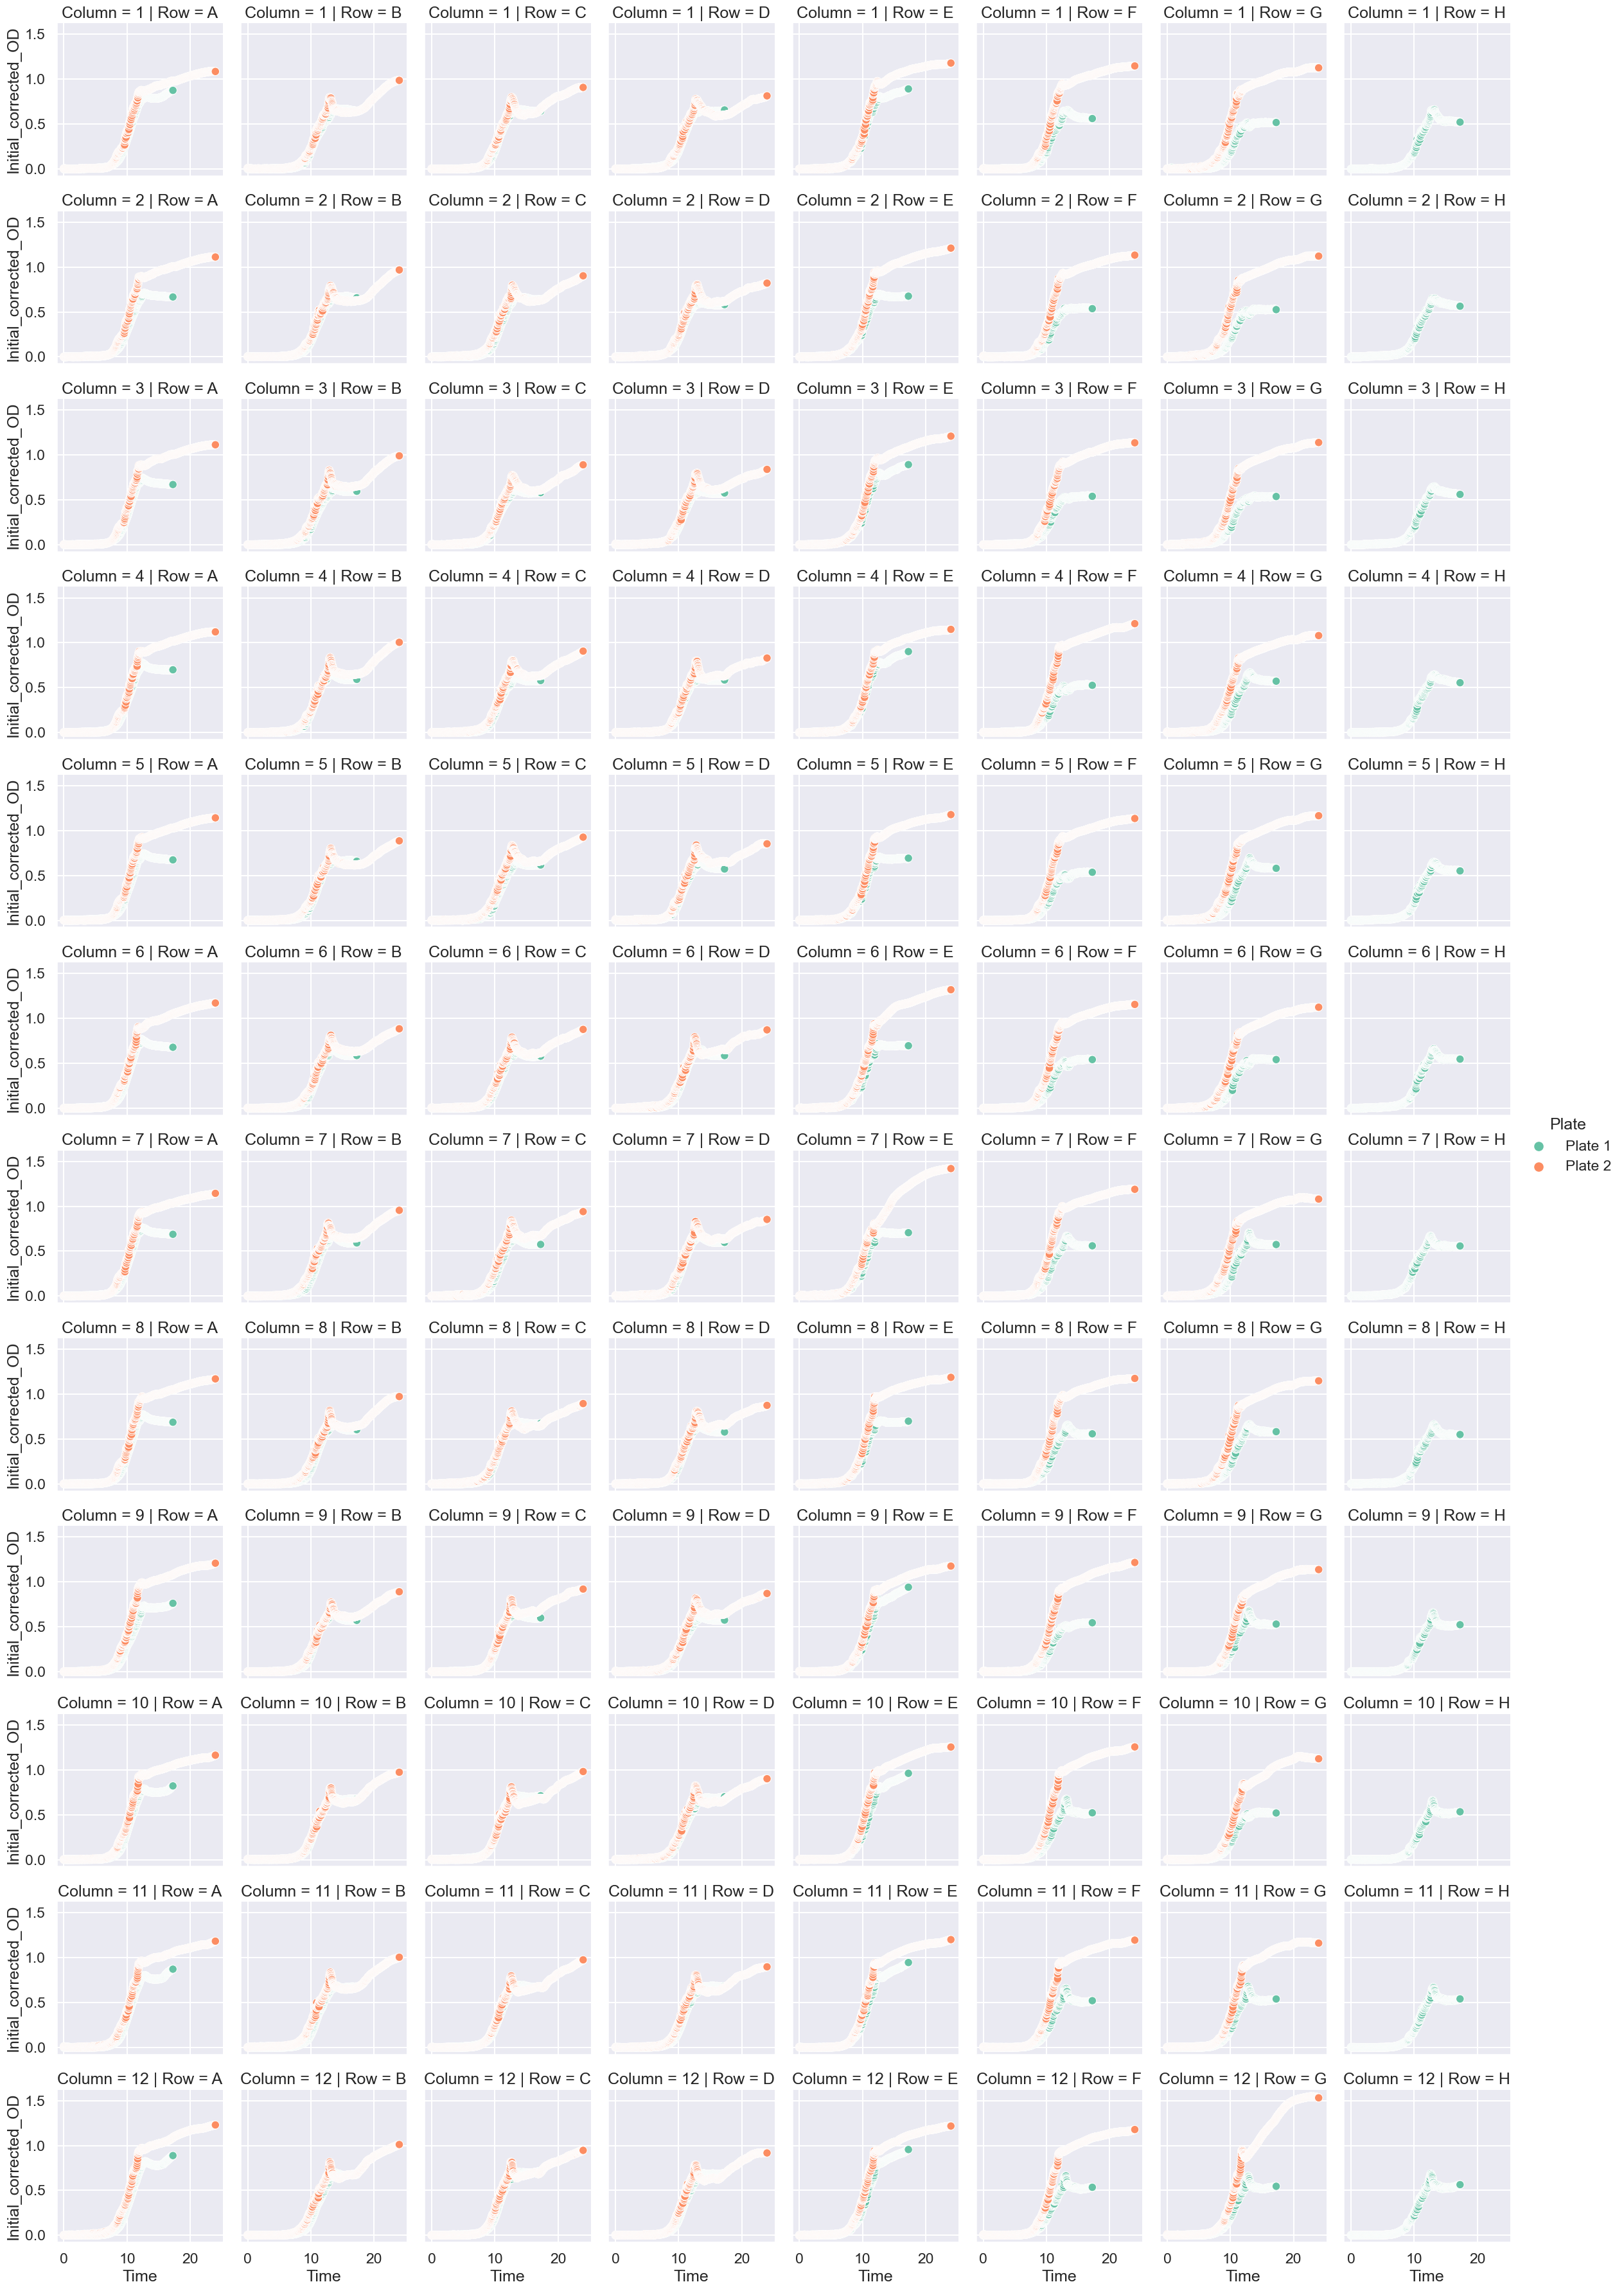

In [275]:
sns.set_context("talk")

sns.relplot(x="Time", y="Initial_corrected_OD", hue="Plate", col="Row", row="Column", \
            # row="Genotype", 
            height=3, \
            # col_wrap=4,
            data=mdf)

In [276]:
f_mdf = mdf.filter(pl.col("Initial_corrected_OD") > 0)

f_mdf = f_mdf.with_columns([
    (pl.col("Initial_corrected_OD").log())
    .alias("Log_initial_corrected_OD")
])

f_mdf.head(5)

Time,Plate,N_replicate,Well,OD,Row,Column,Additive,Genotype,Initial_OD,Replicate,Initial_corrected_OD,Log_initial_corrected_OD
f64,str,i32,str,f64,str,str,str,str,f64,i32,f64,f64
2.211111,"""Plate 1""",12,"""A1""",0.097,"""A""","""1""","""met""","""YkgM1""",0.096,1,0.001,-6.907755
2.336111,"""Plate 1""",12,"""A1""",0.097,"""A""","""1""","""met""","""YkgM1""",0.096,1,0.001,-6.907755
2.361111,"""Plate 1""",12,"""A1""",0.097,"""A""","""1""","""met""","""YkgM1""",0.096,1,0.001,-6.907755
2.536111,"""Plate 1""",12,"""A1""",0.097,"""A""","""1""","""met""","""YkgM1""",0.096,1,0.001,-6.907755
2.561111,"""Plate 1""",12,"""A1""",0.097,"""A""","""1""","""met""","""YkgM1""",0.096,1,0.001,-6.907755


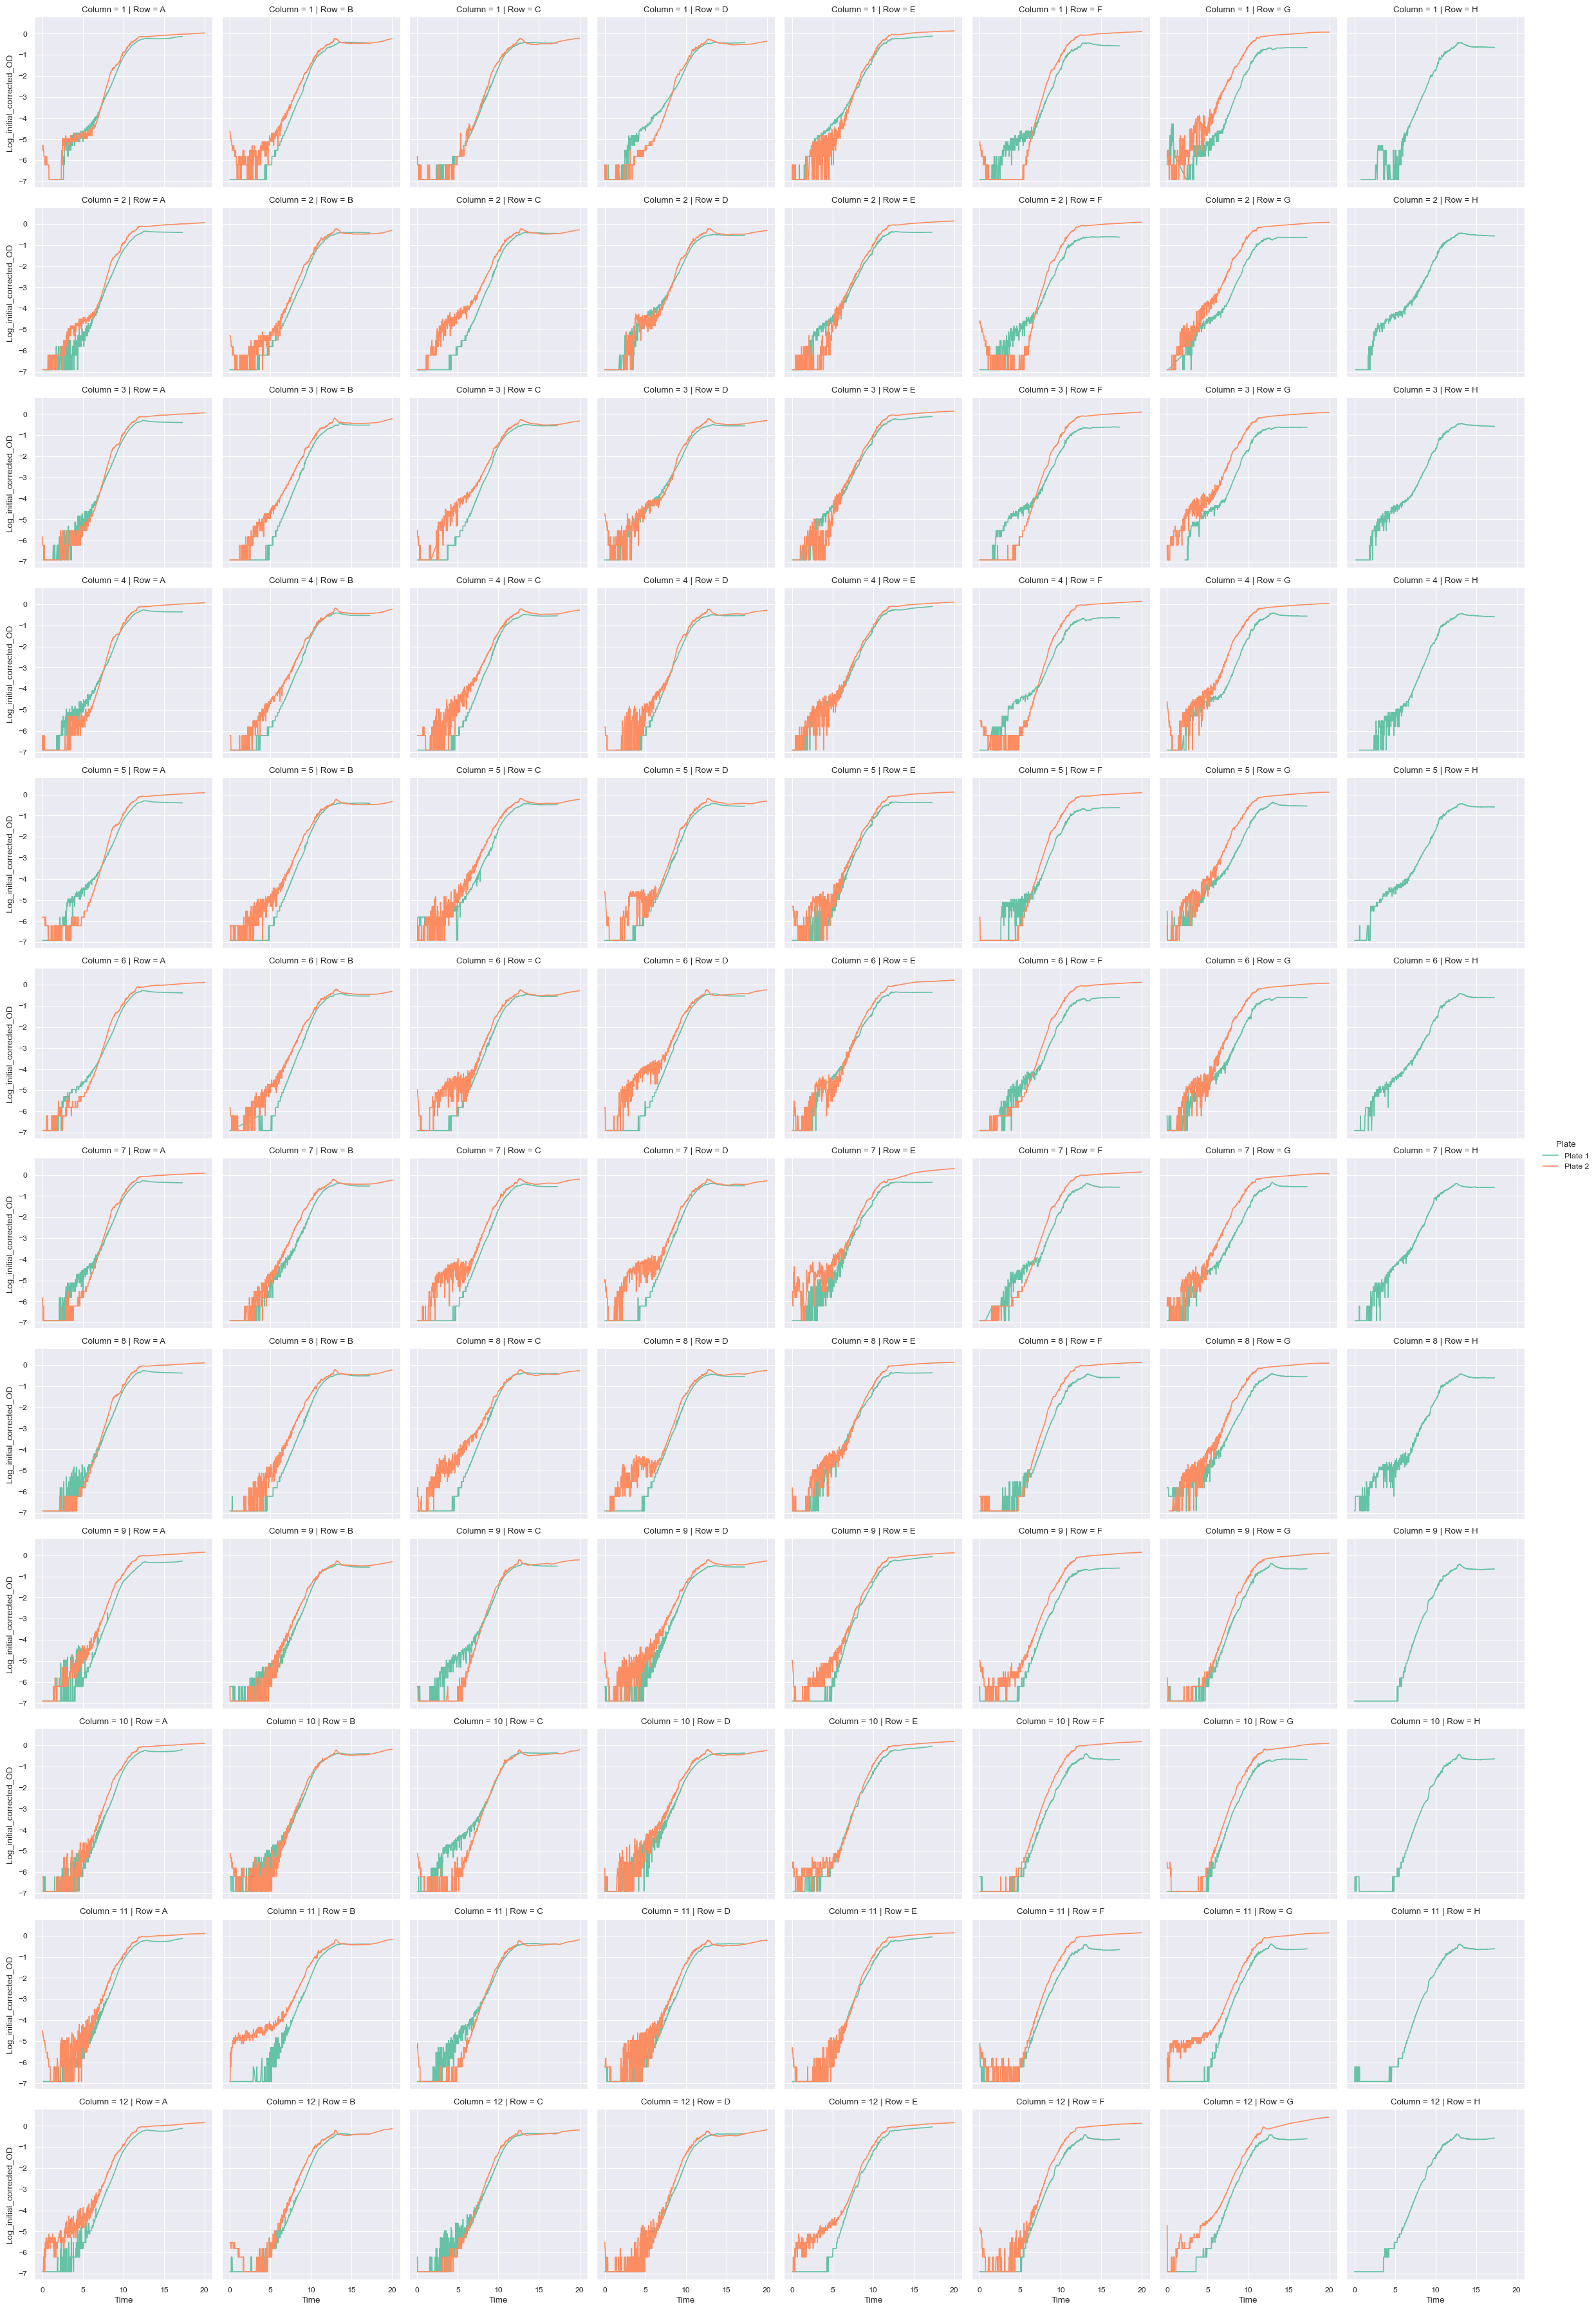

In [287]:
sns.relplot(x="Time", y="Log_initial_corrected_OD", hue="Plate", kind="line", row="Column", col="Row", height=3, \
            data=f_mdf.filter(pl.col("Time") < 20))

plt.savefig("weird_plate.png")

In [278]:
gr_df = f_mdf.filter( (pl.col("Time") < 20))
minimum_start_times = gr_df.filter(pl.col("Log_initial_corrected_OD") <= -4.5).group_by(["Plate", "Well"]).agg(pl.max("Time").alias("Time_exp_start")).sort("Time_exp_start")
minimum_end_times = gr_df.filter(pl.col("Log_initial_corrected_OD") >= -3).group_by(["Plate", "Well"]).agg(pl.min("Time").alias("Time_exp_end")).sort("Time_exp_end")

gr_df = gr_df.join(minimum_start_times, on=["Plate", "Well"])
gr_df = gr_df.join(minimum_end_times, on=["Plate", "Well"])
gr_df = gr_df.filter((pl.col("Time") > pl.col("Time_exp_start")) & (pl.col("Time") < pl.col("Time_exp_end")))
gr_df = gr_df.with_columns((pl.col("Time") - pl.col("Time_exp_start")).alias("Corrected_time"))
gr_df.head(5)

Time,Plate,N_replicate,Well,OD,Row,Column,Additive,Genotype,Initial_OD,Replicate,Initial_corrected_OD,Log_initial_corrected_OD,Time_exp_start,Time_exp_end,Corrected_time
f64,str,i32,str,f64,str,str,str,str,f64,i32,f64,f64,f64,f64,f64
5.961111,"""Plate 1""",12,"""A1""",0.109,"""A""","""1""","""met""","""YkgM1""",0.096,1,0.013,-4.342806,5.936111,7.736111,0.025
5.986111,"""Plate 1""",12,"""A1""",0.109,"""A""","""1""","""met""","""YkgM1""",0.096,1,0.013,-4.342806,5.936111,7.736111,0.05
6.011111,"""Plate 1""",12,"""A1""",0.108,"""A""","""1""","""met""","""YkgM1""",0.096,1,0.012,-4.422849,5.936111,7.736111,0.075
6.036111,"""Plate 1""",12,"""A1""",0.111,"""A""","""1""","""met""","""YkgM1""",0.096,1,0.015,-4.199705,5.936111,7.736111,0.1
6.061111,"""Plate 1""",12,"""A1""",0.11,"""A""","""1""","""met""","""YkgM1""",0.096,1,0.014,-4.268698,5.936111,7.736111,0.125


In [279]:
# regress and pick top x 
predicted_gr = gr_df \
.to_pandas().groupby(['Genotype', 'Additive','Replicate', 'Plate']).apply(regress_error, 'Log_initial_corrected_OD', ['Corrected_time']).reset_index()

N = 5
top_gr = pl.DataFrame(predicted_gr.sort_values(by=["Genotype", "Additive", "Plate", "slope"], ascending=False).groupby(['Genotype', 'Additive', 'Plate']).nth[:N])
top_gr.head(7)

gr_df = gr_df.join(top_gr, on=["Additive", "Plate", "Replicate", "Genotype"])

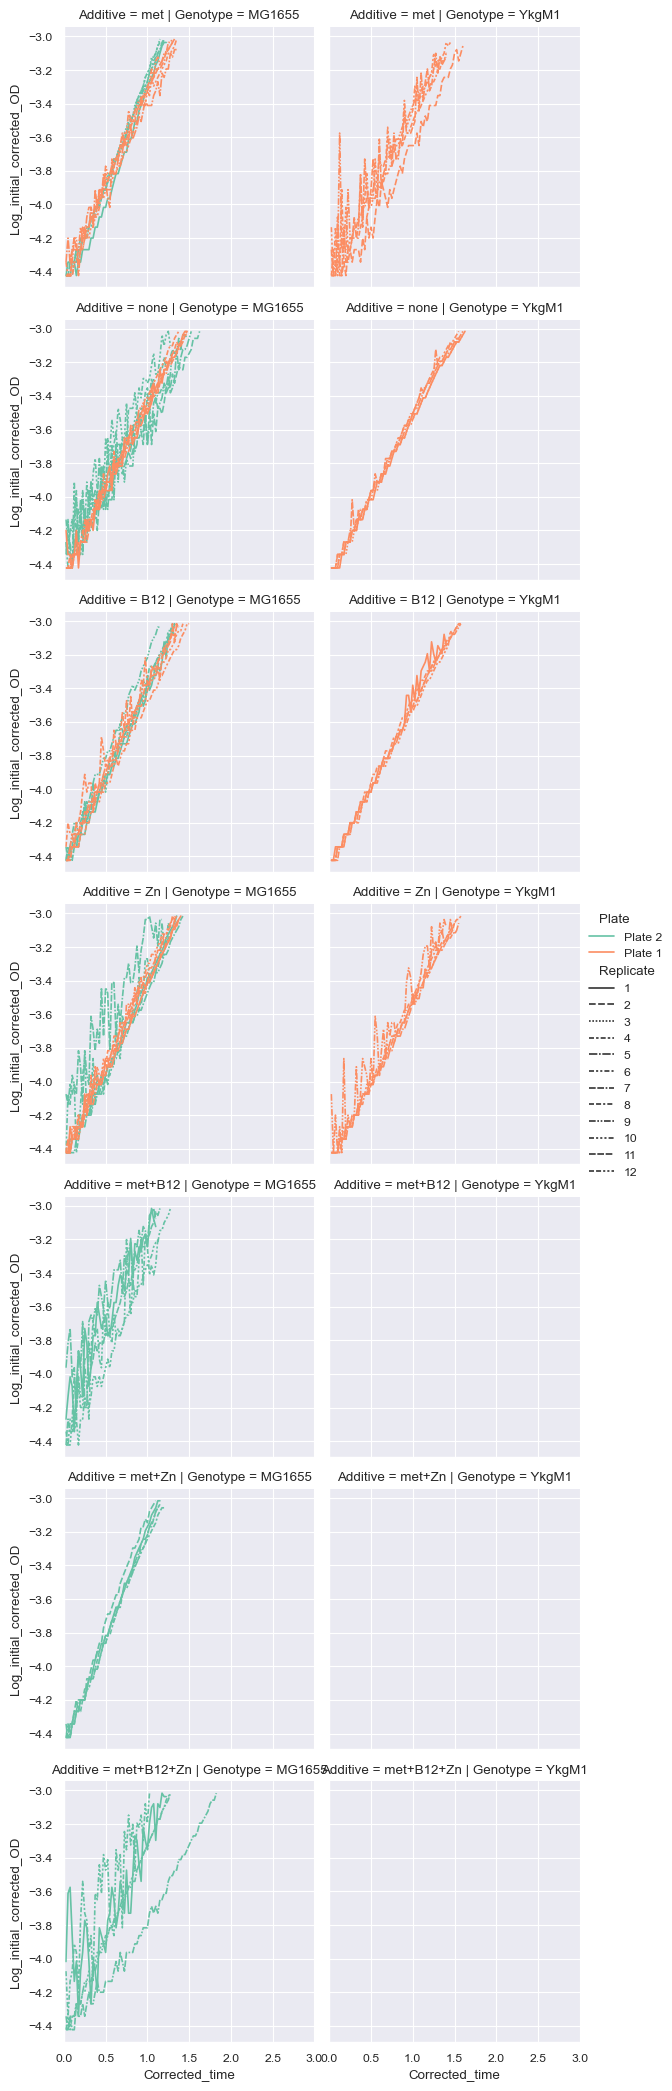

In [286]:
sns.set_context("paper")
sns.relplot(x="Corrected_time", y="Log_initial_corrected_OD", hue="Plate", kind="line", row="Additive", style="Replicate", col="Genotype", height=3, \
            data=gr_df)

plt.xlim([0,3])

plt.savefig("plates.png")

(0.0, 3.0)

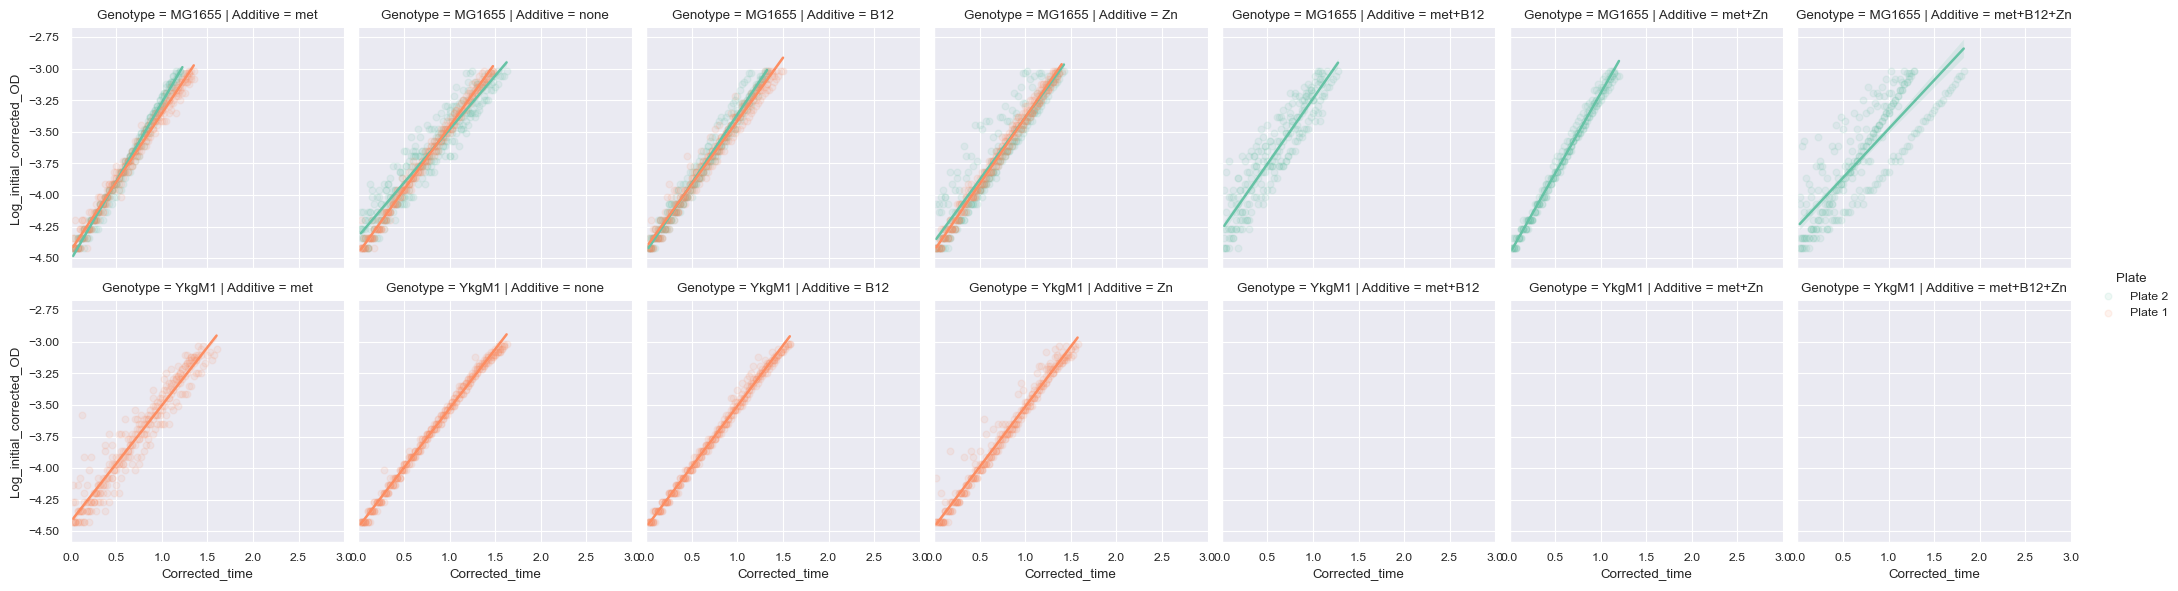

In [281]:
sns.lmplot(x="Corrected_time", y="Log_initial_corrected_OD", hue="Plate", col="Additive", row="Genotype", height=3, \
            data=gr_df.to_pandas(), scatter_kws = {"alpha": 0.1})

plt.xlim([0,3])


In [282]:
# sns.relplot(x="Time", y="Log_initial_corrected_OD", kind="line", row="Replicate", col="Additive", height=3, \
#             data=f_mdf.filter(pl.col("Time") < 15))

In [283]:
# sns.set_context("paper")

# sns.relplot(x="Time", y="Initial_corrected_OD", hue="Plate", style="Replicate", kind="scatter", col="Additive", \
#             # row="Genotype", height=3, \
#             col_wrap=4,
#             data=mdf)

In [284]:
predicted_gr = gr_df \
.to_pandas().groupby(['Genotype', 'Additive','Replicate', 'Plate']).apply(regress_error, 'Log_initial_corrected_OD', ['Corrected_time'])
predicted_gr["doubling_time"] = np.log(2) / predicted_gr["slope"]
predicted_gr = predicted_gr.reset_index()


gr_mean_std = predicted_gr.groupby(['Genotype', 'Additive']).agg({'slope':['mean','std']})
gr_mean_std.columns = gr_mean_std.columns.get_level_values(1)
gr_mean_std["doubling_time"] = np.log(2)/gr_mean_std["mean"]
# gr_mean_std = gr_mean_std.reset_index()

predicted_gr["doubling_time"] = np.log(2)/predicted_gr["slope"]
predicted_gr

,Genotype,Additive,Replicate,Plate,slope,intercept,slope_e,intercept_e,doubling_time
0,MG1655,B12,1,Plate 2,1.077584,-4.492480,0.012154,0.009429,0.643242
1,MG1655,B12,8,Plate 1,0.944204,-4.307628,0.025265,0.020330,0.734107
2,MG1655,B12,9,Plate 1,1.052209,-4.419591,0.008307,0.006565,0.658754
3,MG1655,B12,9,Plate 2,1.203362,-4.409070,0.010228,0.006902,0.576009
4,MG1655,B12,10,Plate 1,1.024863,-4.455974,0.007288,0.006075,0.676332
...,...,...,...,...,...,...,...,...,...
70,YkgM1,none,1,Plate 1,0.926994,-4.476777,0.005784,0.005489,0.747737
71,YkgM1,none,3,Plate 1,0.931821,-4.480416,0.005665,0.005295,0.743863
72,YkgM1,none,5,Plate 1,0.930161,-4.451306,0.005927,0.005540,0.745191
73,YkgM1,none,6,Plate 1,0.961484,-4.464242,0.005637,0.005106,0.720914


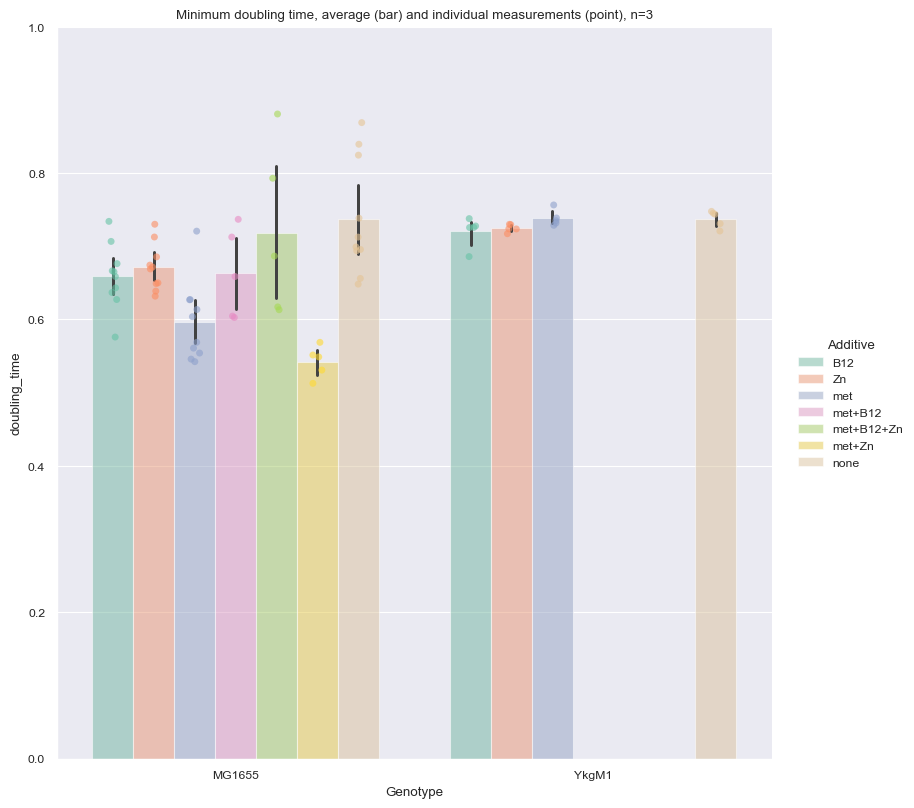

In [285]:
filter_df = pl.DataFrame(predicted_gr) #.filter((pl.col("Plate") == "Plate 2"))
filter_df.head(5)

g = sns.catplot(x="Genotype", y="doubling_time", hue="Additive", 
                data=filter_df.to_pandas(), kind="bar", 
                height=8, aspect=1, alpha=0.5);
g.map_dataframe(sns.stripplot, x="Genotype", y="doubling_time", 
                hue="Additive", palette="Set2",
                alpha=0.6, dodge=True)

plt.title("Minimum doubling time, average (bar) and individual measurements (point), n=3")
# g.map(sns.stripplot, "sex", "total_bill", "smoker", 
#       palette=["#404040"], alpha=0.6, dodge=True)
plt.ylim([0, 1])

plt.show()

g.savefig("story1.png")

# Importing multiple plates

In [185]:
# files = ["growth_data/cyrus_mutant_020124.txt", "growth_data/cyrus_mutants_020224.txt", "growth_data/cyrus_mutants_020624.txt"]
files = [
        "growth_data/cyrus_blue_020824.txt",
        # "growth_data/cyrus_pink_020924.txt"
        ]
# files = ["growth_data/cyrus_mutant_020124.txt", 
#          "growth_data/cyrus_mutants_020224.txt", 
#          "growth_data/cyrus_mutants_020624.txt",
#          "growth_data/cyrus_indigo_020724.txt", 
#          "growth_data/cyrus_pink_020724.txt", 
#          "growth_data/cyrus_blue_failed_020724.txt"
#         ]

# additive = {"A": "met", "B": "none", "C": "B12", "D": "Zn","E": "met+B12", "F": "met+Zn", "G": "met+B12+Zn", "H": "blank"}
additive = {"A": "met", "B": "none", "C": "B12", "D": "Zn","E": "met", "F": "none", "G": "Zn", "H": "B12"}
adf = pl.DataFrame(additive).transpose(include_header=True)
adf = adf.rename({"column": "Row", "column_0": "Additive"})

genotype_row = [["A", "B", "C", "D"], ["E", "F", "G", "H"]]
# genotype_col = [["1", "2", "3", "4"], ["5", "6", "7", "8"], ["9", "10", "11", "12"]]
genotype_col = [["1", "2", "3", "4", "5", "6", "7", "8", "9", "10", "11", "12"]]
# genotype_row = [["A", "B", "C", "D", "E", "F", "G"]]

# genotype_combinations = {"YkgM1": [0, 0], "YkgM2": [0, 1], "MetH": [0, 2], "Zur": [1, 0], "MetE": [1, 1], "MG1655": [1, 2]}
genotype_combinations = {"YkgM1": [0, 0], "MG1655": [1, 0]}
# genotype_combinations = {"MG1655": [0, 0]}

gdf = []

for genotype, idx in genotype_combinations.items():

    gdf.extend([[genotype, x+y] for x in genotype_row[idx[0]] for y in genotype_col[idx[1]]])

gdf

gdf = pl.DataFrame(gdf).transpose()
gdf = gdf.rename({"column_0": "Genotype", "column_1": "Well"})


for i, file in enumerate(files):
    if i == 0:    
        df = pl.read_csv(file, separator="\t") # growth_data/cyrus_mutant_013124.txt
        df = df.with_columns(Plate = pl.lit("Plate 1"))
        df = df.drop('T600')

    else:
        df_add = pl.read_csv(file, separator="\t")
        df_add = df_add.with_columns(Plate = pl.lit(f"Plate {i+1}"))
        df_add = df_add.drop('T600')
        df = pl.concat([df, df_add])

# time conversion
df = df.with_columns(pl.col("Time").str.to_time("%H:%M:%S"))
df = df.with_columns(df['Time'].dt.hour().cast(pl.Int64) + df['Time'].dt.minute().cast(pl.Int64) / 60 + df['Time'].dt.second() / 3600)


# blank_df.head(3)
df.head(3)

Time,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,B1,B2,B3,B4,B5,B6,B7,B8,B9,B10,B11,B12,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,…,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11,F12,G1,G2,G3,G4,G5,G6,G7,G8,G9,G10,G11,G12,H1,H2,H3,H4,H5,H6,H7,H8,H9,H10,H11,H12,Plate
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
0.011111,0.096,0.094,0.096,0.095,0.096,0.097,0.102,0.094,0.093,0.095,0.094,0.095,0.091,0.091,0.092,0.09,0.092,0.092,0.091,0.09,0.091,0.092,0.09,0.09,0.095,0.093,0.095,0.093,0.104,0.094,0.093,0.093,0.096,0.092,0.097,0.095,…,0.093,0.092,0.095,0.093,0.093,0.093,0.092,0.092,0.091,0.091,0.096,0.09,0.095,0.097,0.095,0.094,0.098,0.093,0.095,0.099,0.094,0.093,0.094,0.095,0.095,0.096,0.095,0.094,0.093,0.093,0.092,0.093,0.096,0.092,0.11,0.09,"""Plate 1"""
0.036111,0.096,0.094,0.096,0.095,0.096,0.097,0.102,0.094,0.094,0.095,0.094,0.095,0.091,0.091,0.091,0.09,0.091,0.091,0.091,0.09,0.091,0.092,0.09,0.09,0.095,0.093,0.094,0.093,0.104,0.094,0.093,0.092,0.096,0.092,0.097,0.094,…,0.093,0.092,0.095,0.093,0.092,0.092,0.091,0.092,0.09,0.091,0.096,0.09,0.096,0.097,0.095,0.093,0.097,0.092,0.095,0.099,0.094,0.093,0.094,0.094,0.095,0.096,0.095,0.094,0.093,0.093,0.092,0.093,0.095,0.092,0.11,0.09,"""Plate 1"""
0.061111,0.096,0.094,0.096,0.095,0.096,0.097,0.102,0.094,0.094,0.095,0.094,0.095,0.091,0.091,0.092,0.09,0.091,0.092,0.091,0.09,0.091,0.092,0.09,0.09,0.095,0.093,0.095,0.093,0.105,0.094,0.092,0.092,0.096,0.092,0.097,0.094,…,0.093,0.092,0.095,0.093,0.092,0.093,0.092,0.092,0.09,0.091,0.093,0.09,0.096,0.097,0.095,0.093,0.095,0.092,0.095,0.099,0.094,0.093,0.094,0.094,0.095,0.096,0.095,0.094,0.093,0.093,0.093,0.093,0.095,0.093,0.111,0.09,"""Plate 1"""


In [186]:
# mdf.n_unique(subset=["Plate","Additive","Genotype"])

# mdf.group_by(["Plate","Additive","Genotype"]).n_unique()

# mdf.to_pandas().groupby(["Plate","Additive","Genotype"]).count()

In [187]:
# initial measurement
init_df = df.sort(by="Time").drop(["Time"])[0:200,:].melt(id_vars=["Plate"], variable_name="Well", value_name="Initial_OD")
init_df = init_df.group_by(["Plate", "Well"]).min()

# melt to experiments
mdf = df.melt(id_vars=["Time", "Plate"], variable_name="Well", value_name="OD")
mdf = mdf.with_columns((mdf["Well"].str.slice(0,1)).alias("Row"))
mdf = mdf.with_columns((mdf["Well"].str.slice(1)).alias("Column"))

mdf = mdf.join(adf, on="Row")
mdf = mdf.join(gdf, on="Well")
mdf = mdf.join(init_df, on=["Well", "Plate"])

# mdf = mdf.with_columns(((pl.col("Column").cast(pl.Int32)+3) % 4 + 1).alias("Replicate"))
mdf = mdf.with_columns(((pl.col("Column").cast(pl.Int32)+11) % 12 + 1).alias("Replicate"))

mdf.head(5)



Time,Plate,Well,OD,Row,Column,Additive,Genotype,Initial_OD,Replicate
f64,str,str,f64,str,str,str,str,f64,i32
0.011111,"""Plate 1""","""A1""",0.096,"""A""","""1""","""met""","""YkgM1""",0.096,1
0.036111,"""Plate 1""","""A1""",0.096,"""A""","""1""","""met""","""YkgM1""",0.096,1
0.061111,"""Plate 1""","""A1""",0.096,"""A""","""1""","""met""","""YkgM1""",0.096,1
0.086111,"""Plate 1""","""A1""",0.096,"""A""","""1""","""met""","""YkgM1""",0.096,1
0.111111,"""Plate 1""","""A1""",0.096,"""A""","""1""","""met""","""YkgM1""",0.096,1


In [188]:
mdf = mdf.with_columns([
    (pl.col("OD") - pl.col("Initial_OD")).alias("Initial_corrected_OD"), 
    # (
    #     (pl.col("OD") - pl.col("Background_OD")) / (pl.col("Initial_OD") - pl.col("Background_OD"))  
    # ).alias("Normalized_OD")
])

mdf.head(5)



Time,Plate,Well,OD,Row,Column,Additive,Genotype,Initial_OD,Replicate,Initial_corrected_OD
f64,str,str,f64,str,str,str,str,f64,i32,f64
0.011111,"""Plate 1""","""A1""",0.096,"""A""","""1""","""met""","""YkgM1""",0.096,1,0.0
0.036111,"""Plate 1""","""A1""",0.096,"""A""","""1""","""met""","""YkgM1""",0.096,1,0.0
0.061111,"""Plate 1""","""A1""",0.096,"""A""","""1""","""met""","""YkgM1""",0.096,1,0.0
0.086111,"""Plate 1""","""A1""",0.096,"""A""","""1""","""met""","""YkgM1""",0.096,1,0.0
0.111111,"""Plate 1""","""A1""",0.096,"""A""","""1""","""met""","""YkgM1""",0.096,1,0.0


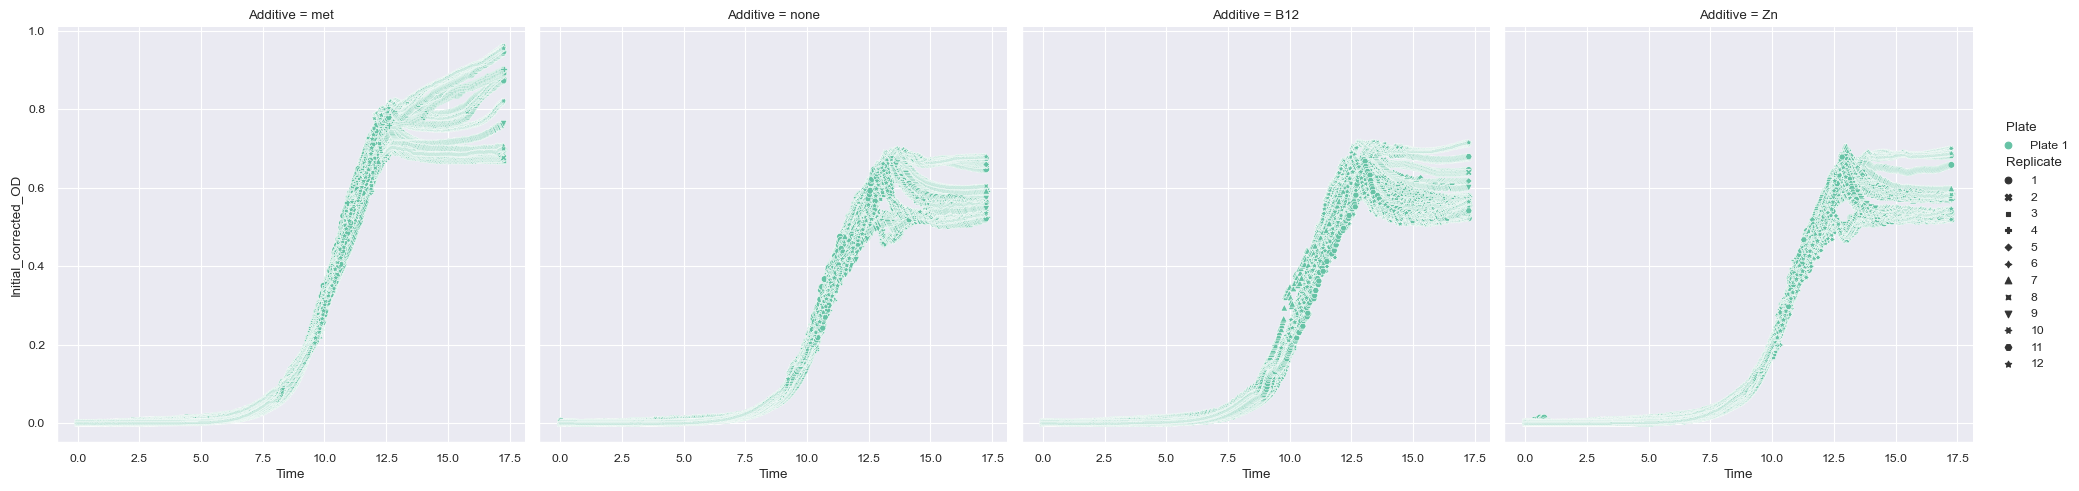

In [189]:
sns.set_context("paper")

sns.relplot(x="Time", y="Initial_corrected_OD", hue="Plate", style="Replicate", kind="scatter", col="Additive", \
            # row="Genotype", height=3, \
            col_wrap=4,
            data=mdf)

In [190]:
f_mdf = mdf.filter(pl.col("Initial_corrected_OD") > 0)

f_mdf = f_mdf.with_columns([
    (pl.col("Initial_corrected_OD").log())
    .alias("Log_initial_corrected_OD")
])

f_mdf.head(5)

Time,Plate,Well,OD,Row,Column,Additive,Genotype,Initial_OD,Replicate,Initial_corrected_OD,Log_initial_corrected_OD
f64,str,str,f64,str,str,str,str,f64,i32,f64,f64
2.211111,"""Plate 1""","""A1""",0.097,"""A""","""1""","""met""","""YkgM1""",0.096,1,0.001,-6.907755
2.336111,"""Plate 1""","""A1""",0.097,"""A""","""1""","""met""","""YkgM1""",0.096,1,0.001,-6.907755
2.361111,"""Plate 1""","""A1""",0.097,"""A""","""1""","""met""","""YkgM1""",0.096,1,0.001,-6.907755
2.536111,"""Plate 1""","""A1""",0.097,"""A""","""1""","""met""","""YkgM1""",0.096,1,0.001,-6.907755
2.561111,"""Plate 1""","""A1""",0.097,"""A""","""1""","""met""","""YkgM1""",0.096,1,0.001,-6.907755


In [191]:
# sns.relplot(x="Time", y="Log_initial_corrected_OD", hue="Plate", style="Replicate", kind="line", col="Additive", row="Genotype", height=3, \
#             data=f_mdf.filter(pl.col("Time") < 10), alpha=0.3)

# sns.relplot(x="Time", y="Log_initial_corrected_OD", hue="Additive", kind="line", row="Replicate", col="Genotype", height=3, \
#             data=f_mdf.filter(pl.col("Time") < 15), alpha=0.3)

sns.relplot(x="Time", y="Log_initial_corrected_OD", kind="line", row="Replicate", col="Additive", height=3, \
            data=f_mdf.filter(pl.col("Time") < 15))

# plt.savefig("Plate_comparison.png")

KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x13aea2b00> (for post_execute):
Error in callback <function flush_figures at 0x29a839990> (for post_execute):



KeyboardInterrupt


KeyboardInterrupt



In [96]:
# good_wells = ["A7", "A8", "A10", 
#               "B8", "B9", "B10", "B12", 
#               "C9", "C10", "C11", "C12", 
#               "D1","D5", "D8", "D12",
#               "E10", "E11", 
#               "F3", "F4", "F5", "F7", "F8", "F9",
#               "G9", "G10"]

# f_mdf = f_mdf.filter(pl.col("Well").is_in(good_wells))

In [97]:
# removing_outliers = f_mdf.filter(
#     (
#         (pl.col("Column").is_in(["9", "10", "11"])) & (pl.col("Genotype") == "MG1655")  
#     ) 
#     # |
#     # (
#     #     (pl.col("Column").is_in(["8", "9","11", "12"])) & (pl.col("Genotype") == "YkgM1")  
#     # )
# )

# f_mdf = removing_outliers

In [114]:
gr_df = f_mdf.filter( (pl.col("Time") < 20))
minimum_start_times = gr_df.filter(pl.col("Log_initial_corrected_OD") <= -4.5).group_by(["Plate", "Well"]).agg(pl.max("Time").alias("Time_exp_start")).sort("Time_exp_start")
minimum_end_times = gr_df.filter(pl.col("Log_initial_corrected_OD") >= -3).group_by(["Plate", "Well"]).agg(pl.min("Time").alias("Time_exp_end")).sort("Time_exp_end")

gr_df = gr_df.join(minimum_start_times, on=["Plate", "Well"])
gr_df = gr_df.join(minimum_end_times, on=["Plate", "Well"])
gr_df = gr_df.filter((pl.col("Time") > pl.col("Time_exp_start")) & (pl.col("Time") < pl.col("Time_exp_end")))
gr_df = gr_df.with_columns((pl.col("Time") - pl.col("Time_exp_start")).alias("Corrected_time"))
gr_df.head(5)

Time,Plate,Well,OD,Row,Column,Additive,Genotype,Initial_OD,Replicate,Initial_corrected_OD,Log_initial_corrected_OD,Time_exp_start,Time_exp_end,Corrected_time
f64,str,str,f64,str,str,str,str,f64,i32,f64,f64,f64,f64,f64
6.361111,"""Plate 1""","""A1""",0.175,"""A""","""1""","""met""","""MG1655""",0.163,1,0.012,-4.422849,6.336111,7.586111,0.025
6.386111,"""Plate 1""","""A1""",0.176,"""A""","""1""","""met""","""MG1655""",0.163,1,0.013,-4.342806,6.336111,7.586111,0.05
6.411111,"""Plate 1""","""A1""",0.176,"""A""","""1""","""met""","""MG1655""",0.163,1,0.013,-4.342806,6.336111,7.586111,0.075
6.436111,"""Plate 1""","""A1""",0.176,"""A""","""1""","""met""","""MG1655""",0.163,1,0.013,-4.342806,6.336111,7.586111,0.1
6.461111,"""Plate 1""","""A1""",0.176,"""A""","""1""","""met""","""MG1655""",0.163,1,0.013,-4.342806,6.336111,7.586111,0.125


In [115]:
# regress and pick top x 
predicted_gr = gr_df \
.to_pandas().groupby(['Genotype', 'Additive','Replicate', 'Plate']).apply(regress_error, 'Log_initial_corrected_OD', ['Corrected_time']).reset_index()

N = 4
top_gr = pl.DataFrame(predicted_gr.sort_values(by=["Genotype", "Additive", "Plate", "slope"], ascending=False).groupby(['Genotype', 'Additive', 'Plate']).nth[:N])
top_gr.head(7)

gr_df = gr_df.join(top_gr, on=["Additive", "Plate", "Replicate", "Genotype"])

(0.0, 3.0)

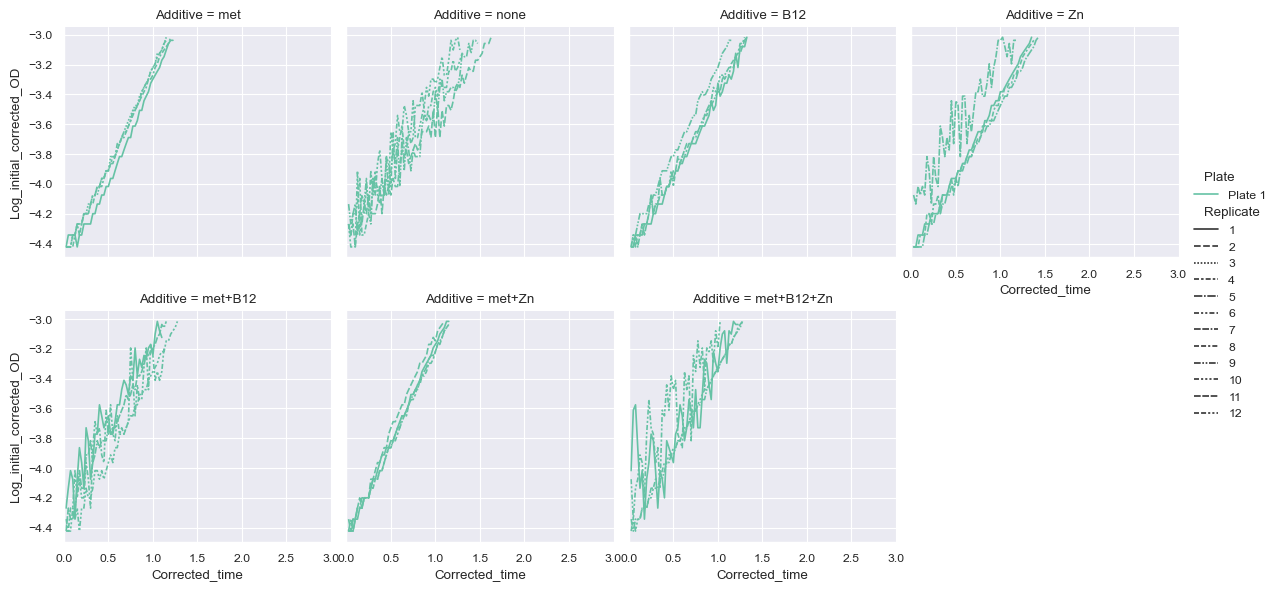

In [116]:
# sns.relplot(x="Corrected_time", y="Log_initial_corrected_OD", hue="Plate", kind="line", col="Additive", style="Replicate", row="Genotype", height=3, \
#             data=gr_df)

sns.relplot(x="Corrected_time", y="Log_initial_corrected_OD", hue="Plate", kind="line", col="Additive", style="Replicate", col_wrap=4, height=3, \
            data=gr_df)

plt.xlim([0,3])

# plt.savefig("shaky.png")

(0.0, 3.0)

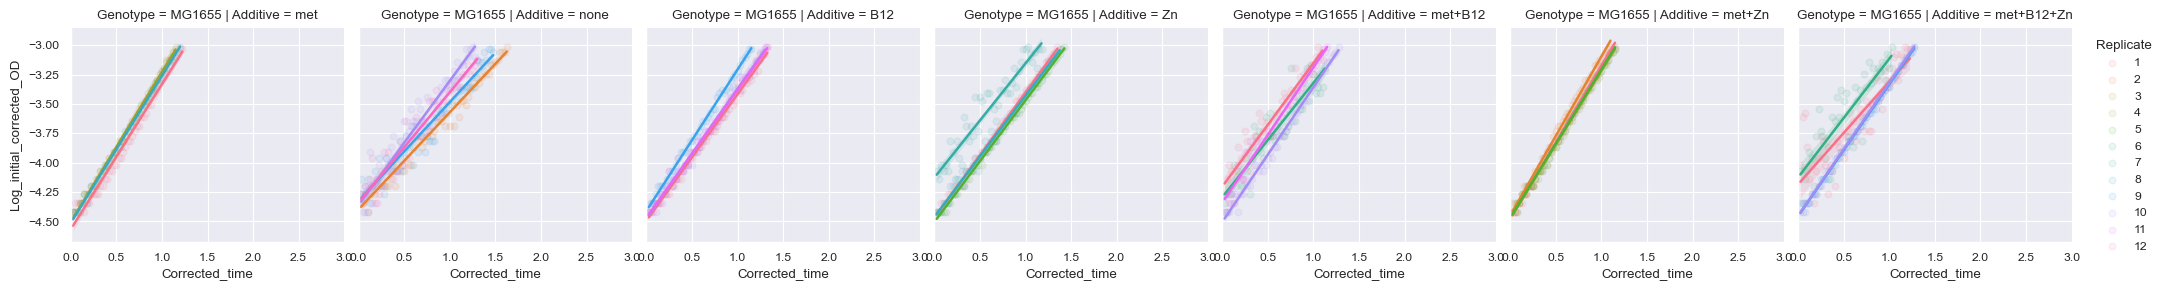

In [117]:
sns.lmplot(x="Corrected_time", y="Log_initial_corrected_OD", hue="Replicate", col="Additive", row="Genotype", height=3, \
            data=gr_df.to_pandas(), scatter_kws = {"alpha": 0.1})

plt.xlim([0,3])


(0.0, 1.5)

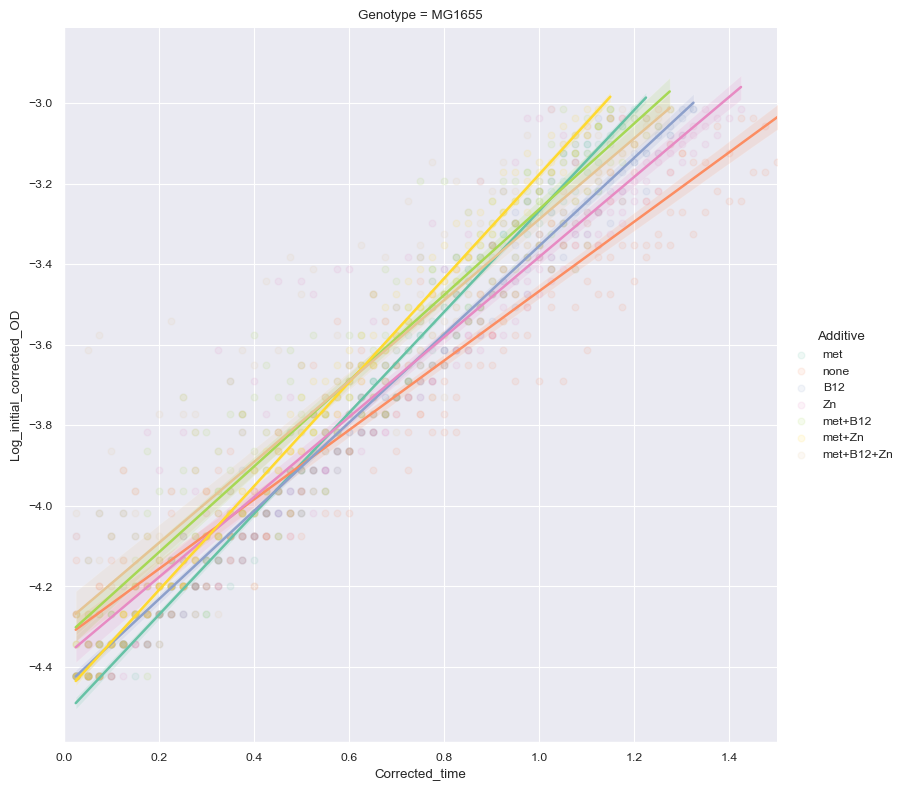

In [118]:
# sns.lmplot(x="Corrected_time", y="Log_initial_corrected_OD", hue="Additive", row="Genotype", height=3, aspect=2, \
#             data=gr_df.to_pandas(), scatter_kws = {"alpha": 0.1})

sns.lmplot(x="Corrected_time", y="Log_initial_corrected_OD", hue="Additive", row="Genotype", height=8, aspect=1, \
            data=gr_df.to_pandas(), scatter_kws = {"alpha": 0.1})

plt.xlim([0,1.5])


In [119]:
predicted_gr = gr_df \
.to_pandas().groupby(['Genotype', 'Additive','Replicate', 'Plate']).apply(regress_error, 'Log_initial_corrected_OD', ['Corrected_time'])
predicted_gr["doubling_time"] = np.log(2) / predicted_gr["slope"]
predicted_gr = predicted_gr.reset_index()


gr_mean_std = predicted_gr.groupby(['Genotype', 'Additive']).agg({'slope':['mean','std']})
gr_mean_std.columns = gr_mean_std.columns.get_level_values(1)
gr_mean_std["doubling_time"] = np.log(2)/gr_mean_std["mean"]
# gr_mean_std = gr_mean_std.reset_index()

predicted_gr["doubling_time"] = np.log(2)/predicted_gr["slope"]
predicted_gr

,Genotype,Additive,Replicate,Plate,slope,intercept,slope_e,intercept_e,doubling_time
0,MG1655,B12,1,Plate 1,1.077584,-4.492480,0.012154,0.009429,0.643242
1,MG1655,B12,9,Plate 1,1.203362,-4.409070,0.010228,0.006902,0.576009
2,MG1655,B12,10,Plate 1,1.104971,-4.474457,0.013654,0.010396,0.627299
3,MG1655,B12,11,Plate 1,1.088362,-4.466474,0.012554,0.009740,0.636872
4,MG1655,Zn,1,Plate 1,1.066323,-4.468933,0.006829,0.005396,0.650035
5,MG1655,Zn,5,Plate 1,1.035982,-4.503894,0.006418,0.005349,0.669073
6,MG1655,Zn,7,Plate 1,0.972550,-4.127032,0.050302,0.034668,0.712711
7,MG1655,Zn,8,Plate 1,1.032032,-4.461839,0.011287,0.009082,0.671633
8,MG1655,met,1,Plate 1,1.235843,-4.568236,0.022128,0.015889,0.560870
9,MG1655,met,3,Plate 1,1.278010,-4.506037,0.010048,0.006780,0.542365


(0.0, 1.0)

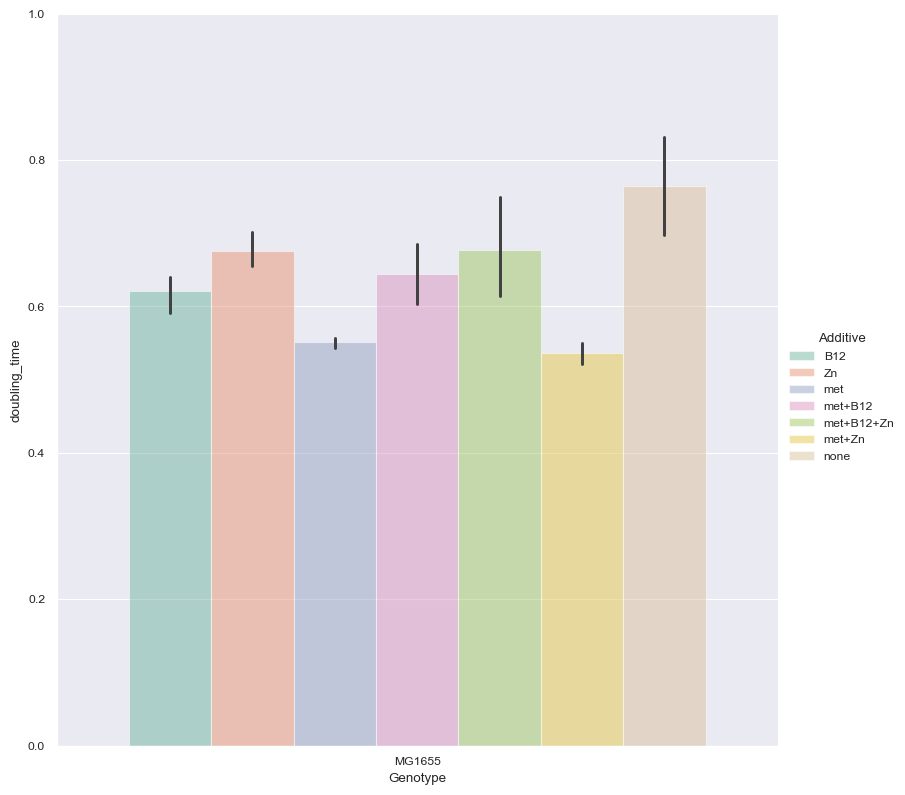

In [120]:
g = sns.catplot(x="Genotype", y="doubling_time", hue="Additive", 
                data=predicted_gr, kind="bar",
                height=8, aspect=1, alpha=0.5);

plt.ylim([0,1])

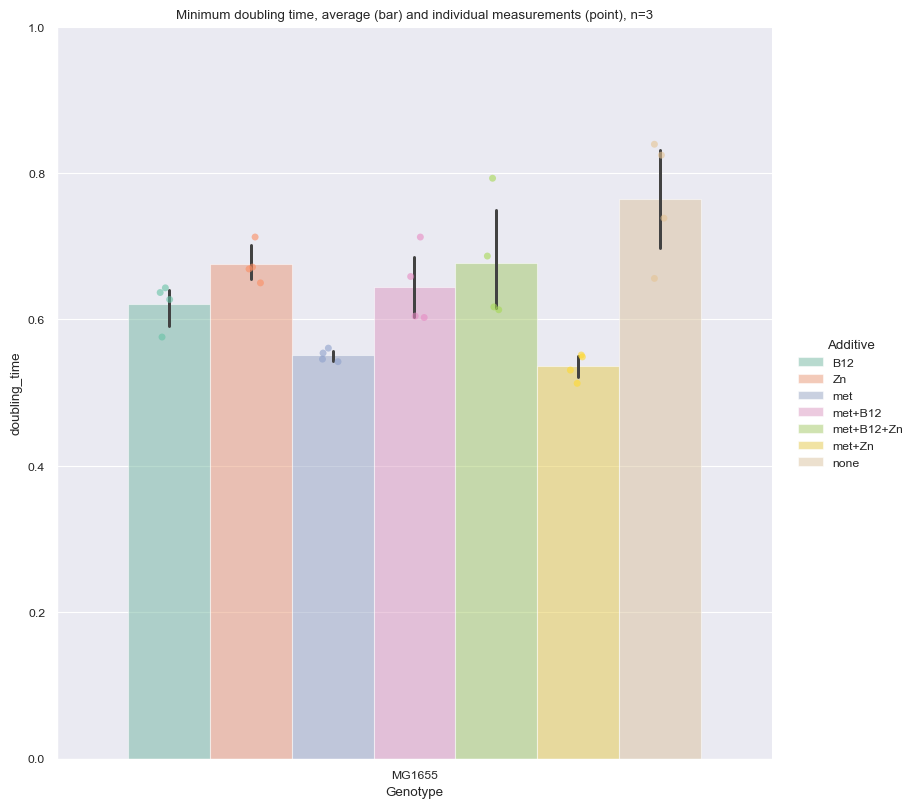

In [121]:
filter_df = pl.DataFrame(predicted_gr) #.filter((pl.col("Plate") == "Plate 2"))
filter_df.head(5)

g = sns.catplot(x="Genotype", y="doubling_time", hue="Additive", 
                data=filter_df.to_pandas(), kind="bar", 
                height=8, aspect=1, alpha=0.5);
g.map_dataframe(sns.stripplot, x="Genotype", y="doubling_time", 
                hue="Additive", palette="Set2",
                alpha=0.6, dodge=True)

plt.title("Minimum doubling time, average (bar) and individual measurements (point), n=3")
# g.map(sns.stripplot, "sex", "total_bill", "smoker", 
#       palette=["#404040"], alpha=0.6, dodge=True)
plt.ylim([0, 1])

plt.show()

g.savefig("story1.png")

# Mut day two

## Importing data

In [74]:
additive = {"A": "met", "B": "none", "C": "B12", "D": "Zn","E": "met", "F": "none", "G": "B12", "H": "Zn"}
adf = pl.DataFrame(additive).transpose(include_header=True)
adf = adf.rename({"column": "Row", "column_0": "Additive"})

genotype_row = [["A", "B", "C", "D"], ["E", "F", "G", "H"]]
genotype_col = [["1", "2", "3", "4"], ["5", "6", "7", "8"], ["9", "10", "11", "12"]]

genotype_combinations = {"YkgM1": [0, 0], "YkgM2": [0, 1], "MetH": [0, 2], "Zur": [1, 0], "MetE": [1, 1], "MG1655": [1, 2]}

gdf = []

for genotype, idx in genotype_combinations.items():

    gdf.extend([[genotype, x+y] for x in genotype_row[idx[0]] for y in genotype_col[idx[1]]])

gdf

gdf = pl.DataFrame(gdf).transpose()
gdf = gdf.rename({"column_0": "Genotype", "column_1": "Well"})

df = pl.read_csv("growth_data/cyrus_mutant_020124.txt", separator="\t")
df = df.drop('T600')
df.head(3)

blank_df = pl.read_csv("growth_data/cyrus_mutant_blanks_020124.txt", separator="\t")
blank_df = blank_df.drop(['T600', 'Time']).mean().transpose(include_header=True)
blank_df = blank_df.rename({"column": "Well", "column_0": "Background_OD"})
blank_df.head(3)

Well,Background_OD
str,f64
"""A1""",0.094238
"""A2""",0.137952
"""A3""",0.179333


In [75]:
# time conversion
df = df.with_columns(pl.col("Time").str.to_time("%H:%M:%S"))
df = df.with_columns(df['Time'].dt.hour().cast(pl.Int64) + df['Time'].dt.minute().cast(pl.Int64) / 60 + df['Time'].dt.second() / 3600)

# initial measurement
init_df = df.drop("Time")[0:100,:].min().transpose(include_header=True)
init_df = init_df.rename({"column": "Well", "column_0": "Initial_OD"})

# melt to experiments
mdf = df.melt(id_vars="Time", variable_name="Well", value_name="OD")
mdf = mdf.with_columns((mdf["Well"].str.slice(0,1)).alias("Row"))
mdf = mdf.with_columns((mdf["Well"].str.slice(1)).alias("Column"))

mdf = mdf.join(adf, on="Row")
mdf = mdf.join(gdf, on="Well")
mdf = mdf.join(blank_df, on="Well")
mdf = mdf.join(init_df, on="Well")

mdf = mdf.with_columns(((pl.col("Column").cast(pl.Int32)+3) % 4 + 1).alias("Replicate"))

mdf



Time,Well,OD,Row,Column,Additive,Genotype,Background_OD,Initial_OD,Replicate
f64,str,f64,str,str,str,str,f64,f64,i32
0.011111,"""A1""",0.171,"""A""","""1""","""met""","""YkgM1""",0.094238,0.166,1
0.036111,"""A1""",0.171,"""A""","""1""","""met""","""YkgM1""",0.094238,0.166,1
0.061111,"""A1""",0.169,"""A""","""1""","""met""","""YkgM1""",0.094238,0.166,1
0.086111,"""A1""",0.168,"""A""","""1""","""met""","""YkgM1""",0.094238,0.166,1
0.111111,"""A1""",0.169,"""A""","""1""","""met""","""YkgM1""",0.094238,0.166,1
0.136111,"""A1""",0.169,"""A""","""1""","""met""","""YkgM1""",0.094238,0.166,1
0.161111,"""A1""",0.167,"""A""","""1""","""met""","""YkgM1""",0.094238,0.166,1
0.186111,"""A1""",0.168,"""A""","""1""","""met""","""YkgM1""",0.094238,0.166,1
0.211111,"""A1""",0.167,"""A""","""1""","""met""","""YkgM1""",0.094238,0.166,1


In [76]:
mdf = mdf.with_columns([
    (pl.col("OD") - pl.col("Background_OD")).alias("Background_corrected_OD"), 
    (pl.col("OD") - pl.col("Initial_OD")).alias("Initial_corrected_OD"), 
    # (
    #     (pl.col("OD") - pl.col("Background_OD")) / (pl.col("Initial_OD") - pl.col("Background_OD"))  
    # ).alias("Normalized_OD")
])

mdf.head(5)



Time,Well,OD,Row,Column,Additive,Genotype,Background_OD,Initial_OD,Replicate,Background_corrected_OD,Initial_corrected_OD
f64,str,f64,str,str,str,str,f64,f64,i32,f64,f64
0.011111,"""A1""",0.171,"""A""","""1""","""met""","""YkgM1""",0.094238,0.166,1,0.076762,0.005
0.036111,"""A1""",0.171,"""A""","""1""","""met""","""YkgM1""",0.094238,0.166,1,0.076762,0.005
0.061111,"""A1""",0.169,"""A""","""1""","""met""","""YkgM1""",0.094238,0.166,1,0.074762,0.003
0.086111,"""A1""",0.168,"""A""","""1""","""met""","""YkgM1""",0.094238,0.166,1,0.073762,0.002
0.111111,"""A1""",0.169,"""A""","""1""","""met""","""YkgM1""",0.094238,0.166,1,0.074762,0.003


## Plot raw data

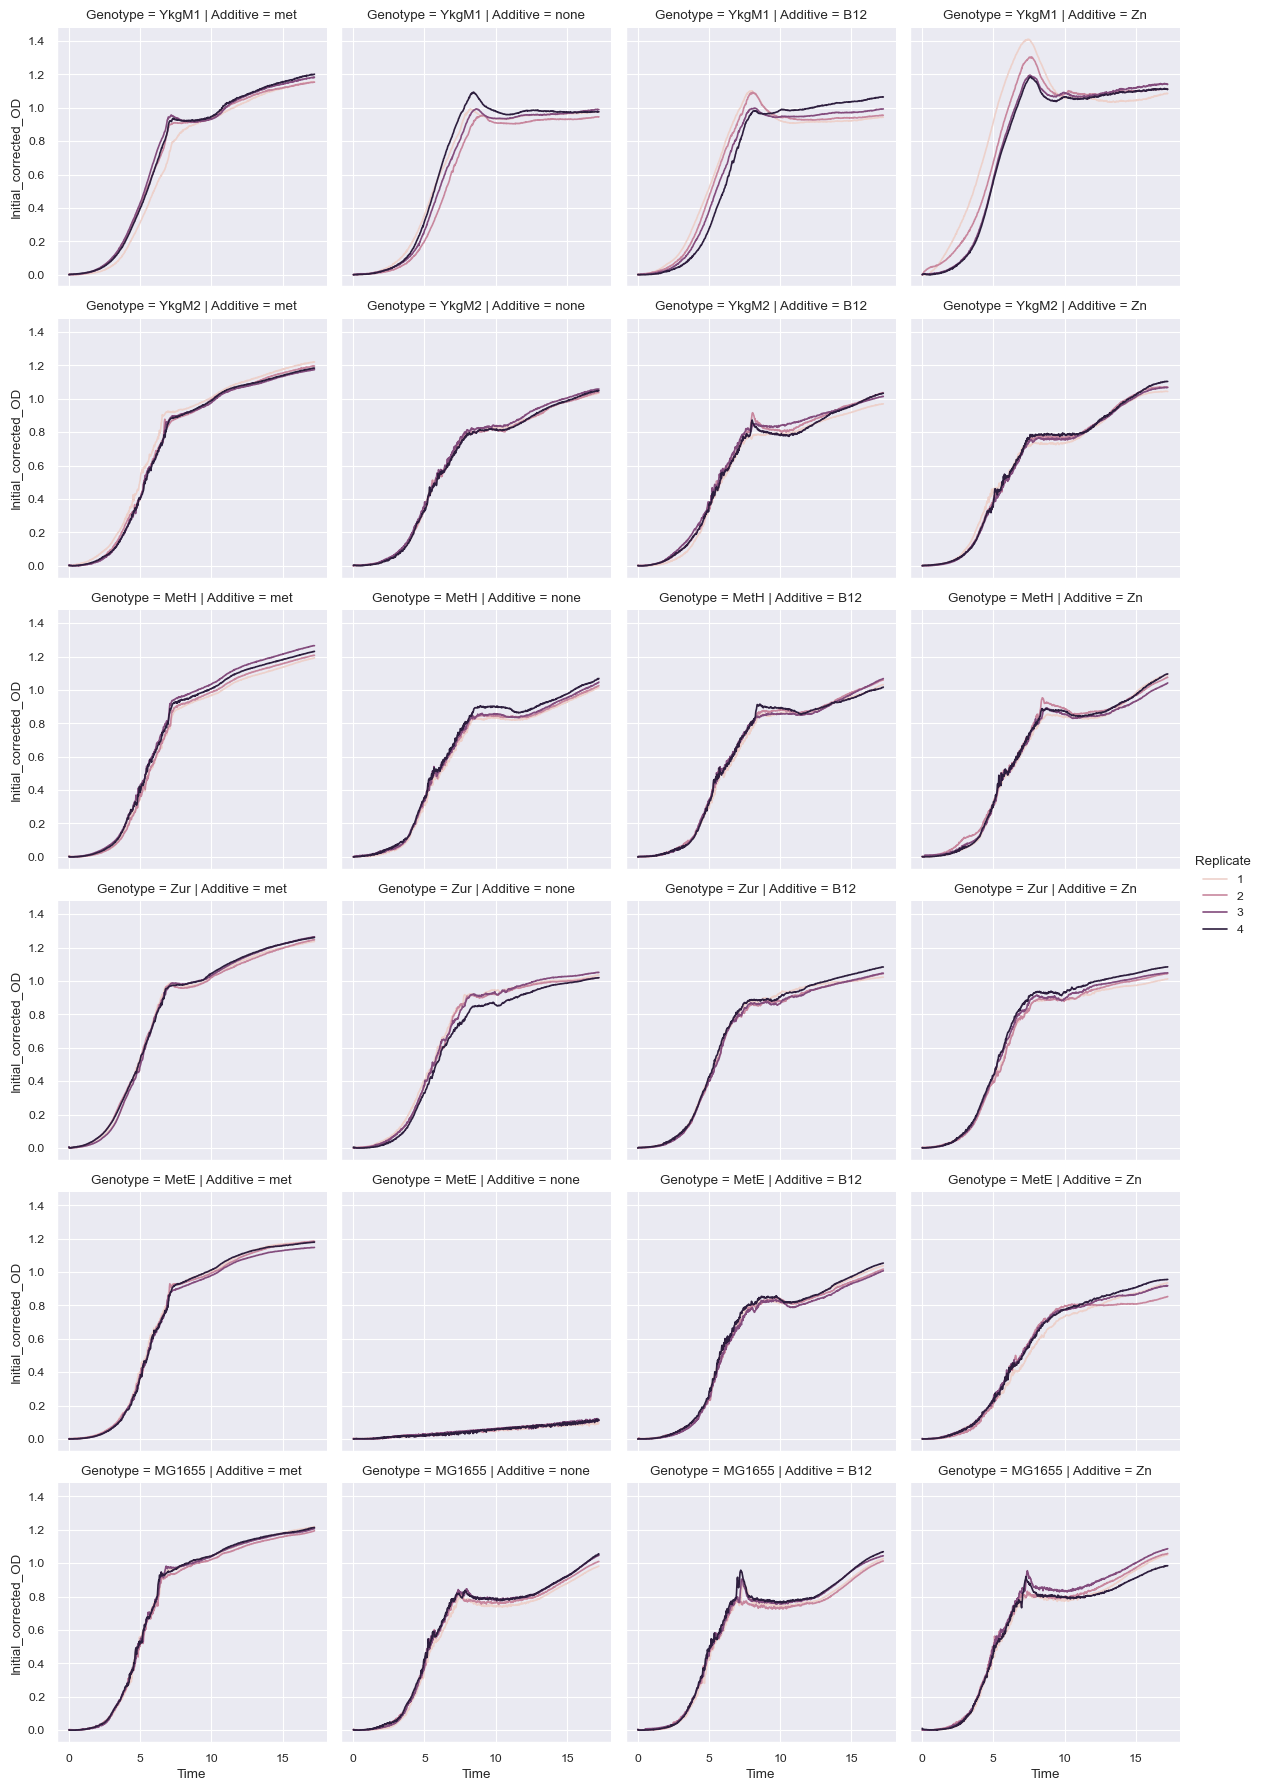

In [77]:
sns.relplot(x="Time", y="Initial_corrected_OD", hue="Replicate", kind="line", col="Additive", row="Genotype", height=3, \
            data=mdf)

## Get growth rates

In [78]:
f_mdf = mdf.filter(pl.col("Initial_corrected_OD") > 0)

f_mdf = f_mdf.with_columns([
    (pl.col("Initial_corrected_OD").log())
    .alias("Log_initial_corrected_OD")
])

f_mdf.head(5)

Time,Well,OD,Row,Column,Additive,Genotype,Background_OD,Initial_OD,Replicate,Background_corrected_OD,Initial_corrected_OD,Log_initial_corrected_OD
f64,str,f64,str,str,str,str,f64,f64,i32,f64,f64,f64
0.011111,"""A1""",0.171,"""A""","""1""","""met""","""YkgM1""",0.094238,0.166,1,0.076762,0.005,-5.298317
0.036111,"""A1""",0.171,"""A""","""1""","""met""","""YkgM1""",0.094238,0.166,1,0.076762,0.005,-5.298317
0.061111,"""A1""",0.169,"""A""","""1""","""met""","""YkgM1""",0.094238,0.166,1,0.074762,0.003,-5.809143
0.086111,"""A1""",0.168,"""A""","""1""","""met""","""YkgM1""",0.094238,0.166,1,0.073762,0.002,-6.214608
0.111111,"""A1""",0.169,"""A""","""1""","""met""","""YkgM1""",0.094238,0.166,1,0.074762,0.003,-5.809143


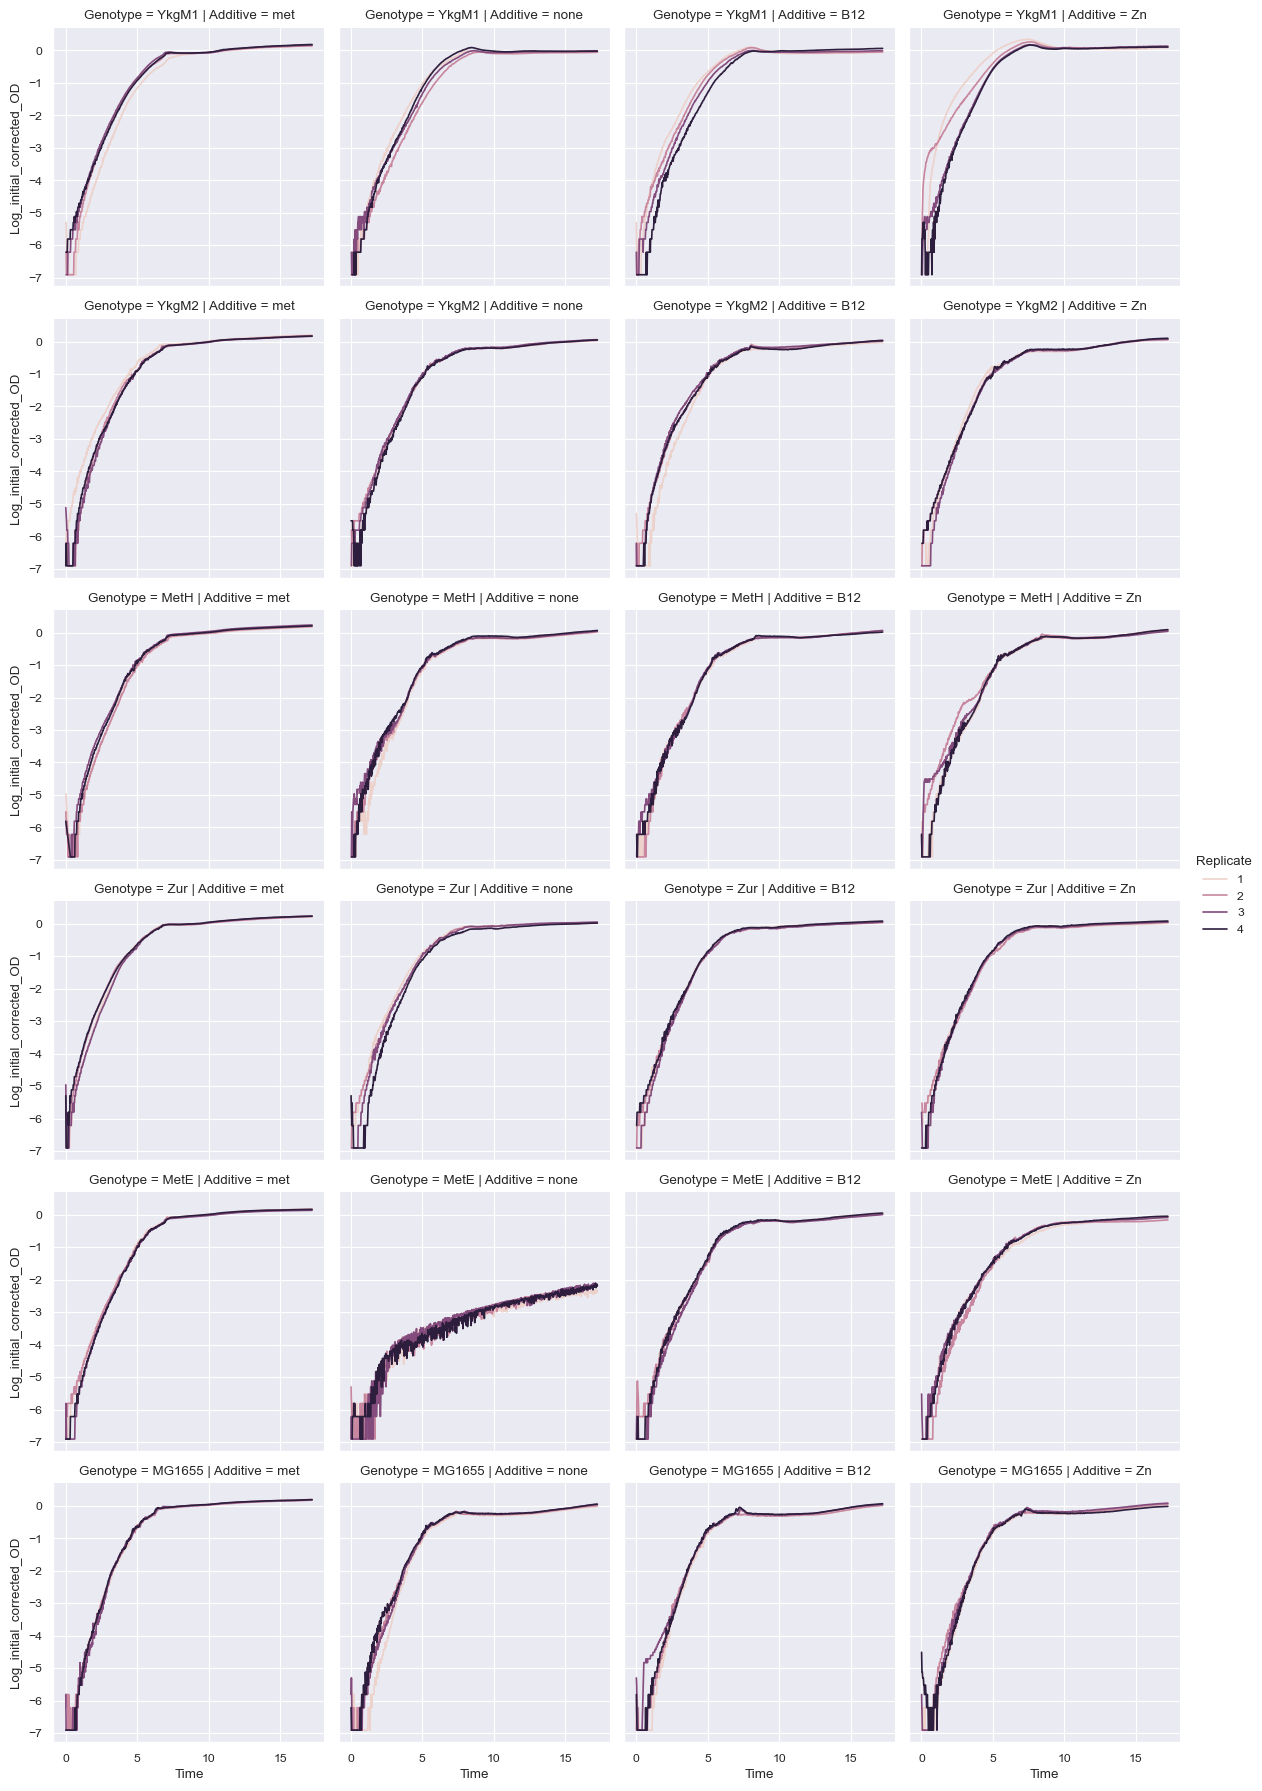

In [79]:
sns.relplot(x="Time", y="Log_initial_corrected_OD", hue="Replicate", kind="line", col="Additive", row="Genotype", height=3, \
            data=f_mdf)

In [80]:
gr_df = f_mdf.filter( (pl.col("Time") < 10))
minimum_start_times = gr_df.filter(pl.col("Log_initial_corrected_OD") <= -4.5).group_by("Well").agg(pl.max("Time").alias("Time_exp_start")).sort("Time_exp_start")
minimum_end_times = gr_df.filter(pl.col("Log_initial_corrected_OD") >= -2).group_by("Well").agg(pl.min("Time").alias("Time_exp_end")).sort("Time_exp_end")

gr_df = gr_df.join(minimum_start_times, on="Well")
gr_df = gr_df.join(minimum_end_times, on="Well")
gr_df = gr_df.filter((pl.col("Time") > pl.col("Time_exp_start")) & (pl.col("Time") < pl.col("Time_exp_end")))
gr_df = gr_df.with_columns((pl.col("Time") - pl.col("Time_exp_start")).alias("Corrected_time"))
gr_df

Time,Well,OD,Row,Column,Additive,Genotype,Background_OD,Initial_OD,Replicate,Background_corrected_OD,Initial_corrected_OD,Log_initial_corrected_OD,Time_exp_start,Time_exp_end,Corrected_time
f64,str,f64,str,str,str,str,f64,f64,i32,f64,f64,f64,f64,f64,f64
1.811111,"""A1""",0.178,"""A""","""1""","""met""","""YkgM1""",0.094238,0.166,1,0.083762,0.012,-4.422849,1.786111,3.911111,0.025
1.836111,"""A1""",0.178,"""A""","""1""","""met""","""YkgM1""",0.094238,0.166,1,0.083762,0.012,-4.422849,1.786111,3.911111,0.05
1.861111,"""A1""",0.178,"""A""","""1""","""met""","""YkgM1""",0.094238,0.166,1,0.083762,0.012,-4.422849,1.786111,3.911111,0.075
1.886111,"""A1""",0.18,"""A""","""1""","""met""","""YkgM1""",0.094238,0.166,1,0.085762,0.014,-4.268698,1.786111,3.911111,0.1
1.911111,"""A1""",0.18,"""A""","""1""","""met""","""YkgM1""",0.094238,0.166,1,0.085762,0.014,-4.268698,1.786111,3.911111,0.125
1.936111,"""A1""",0.18,"""A""","""1""","""met""","""YkgM1""",0.094238,0.166,1,0.085762,0.014,-4.268698,1.786111,3.911111,0.15
1.961111,"""A1""",0.18,"""A""","""1""","""met""","""YkgM1""",0.094238,0.166,1,0.085762,0.014,-4.268698,1.786111,3.911111,0.175
1.986111,"""A1""",0.181,"""A""","""1""","""met""","""YkgM1""",0.094238,0.166,1,0.086762,0.015,-4.199705,1.786111,3.911111,0.2
2.011111,"""A1""",0.181,"""A""","""1""","""met""","""YkgM1""",0.094238,0.166,1,0.086762,0.015,-4.199705,1.786111,3.911111,0.225


(0.0, 4.0)

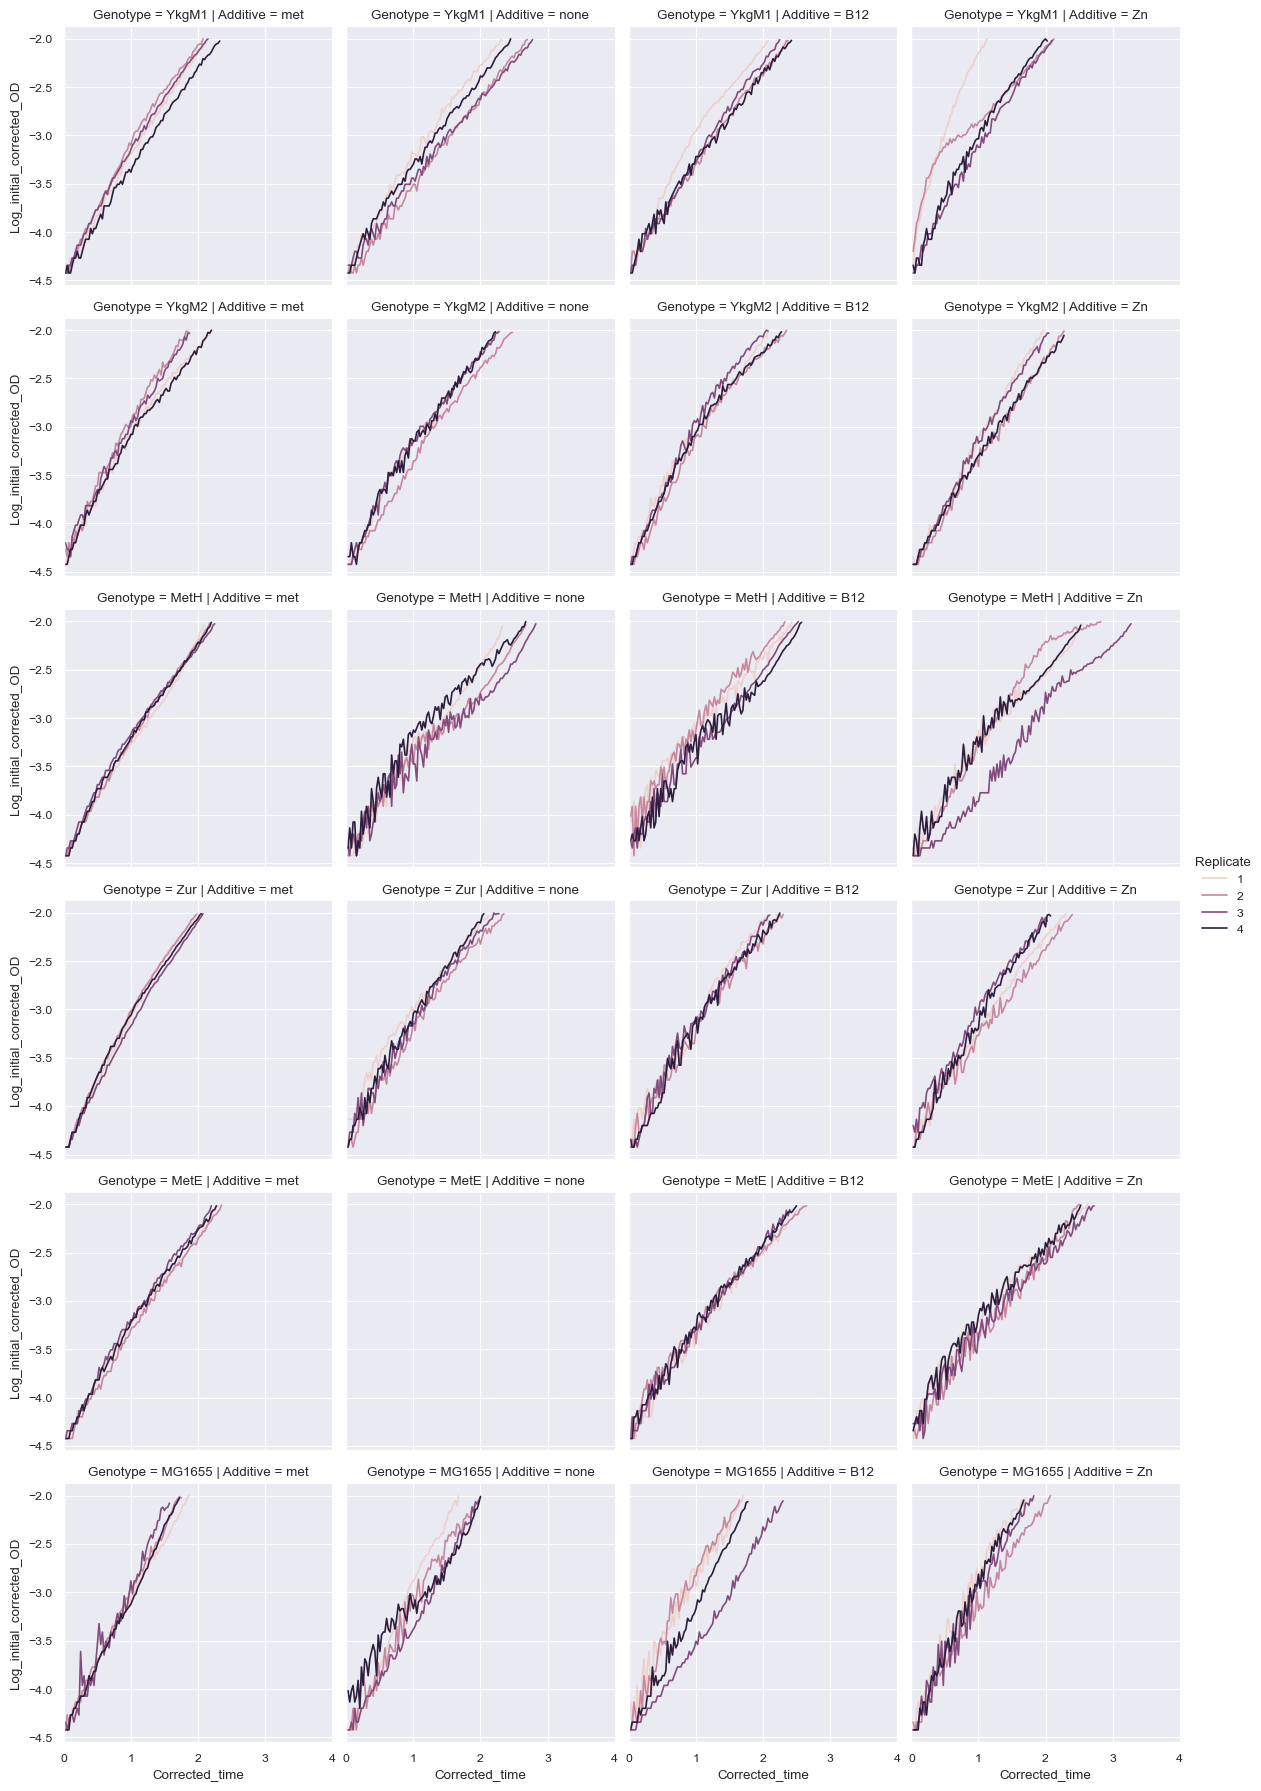

In [81]:
sns.relplot(x="Corrected_time", y="Log_initial_corrected_OD", hue="Replicate", kind="line", col="Additive", row="Genotype", height=3, \
            data=gr_df)

plt.xlim([0,4])

In [82]:
predicted_gr = gr_df \
.to_pandas().groupby(['Genotype', 'Additive','Replicate']).apply(regress_error, 'Log_initial_corrected_OD', ['Corrected_time'])
predicted_gr["doubling_time"] = np.log(2) / predicted_gr["slope"]
predicted_gr = predicted_gr.reset_index()


gr_mean_std = predicted_gr.groupby(['Genotype', 'Additive']).agg({'slope':['mean','std']})
gr_mean_std.columns = gr_mean_std.columns.get_level_values(1)
gr_mean_std["doubling_time"] = np.log(2)/gr_mean_std["mean"]
# gr_mean_std = gr_mean_std.reset_index()

predicted_gr["doubling_time"] = np.log(2)/predicted_gr["slope"]
predicted_gr

,Genotype,Additive,Replicate,slope,intercept,slope_e,intercept_e,doubling_time
0,MG1655,B12,1,1.324157,-4.212585,0.034644,0.034378,0.523463
1,MG1655,B12,2,1.427234,-4.281178,0.031208,0.030067,0.485658
2,MG1655,B12,3,1.066257,-4.564200,0.009580,0.012825,0.650075
3,MG1655,B12,4,1.347420,-4.479041,0.013150,0.013619,0.514426
4,MG1655,Zn,1,1.431332,-4.309911,0.028843,0.028621,0.484267
...,...,...,...,...,...,...,...,...
87,Zur,met,4,1.190536,-4.325590,0.014427,0.017232,0.582215
88,Zur,none,1,0.986011,-4.028845,0.013609,0.016844,0.702981
89,Zur,none,2,1.039713,-4.312025,0.012869,0.017600,0.666672
90,Zur,none,3,1.050107,-4.238075,0.013530,0.017918,0.660073


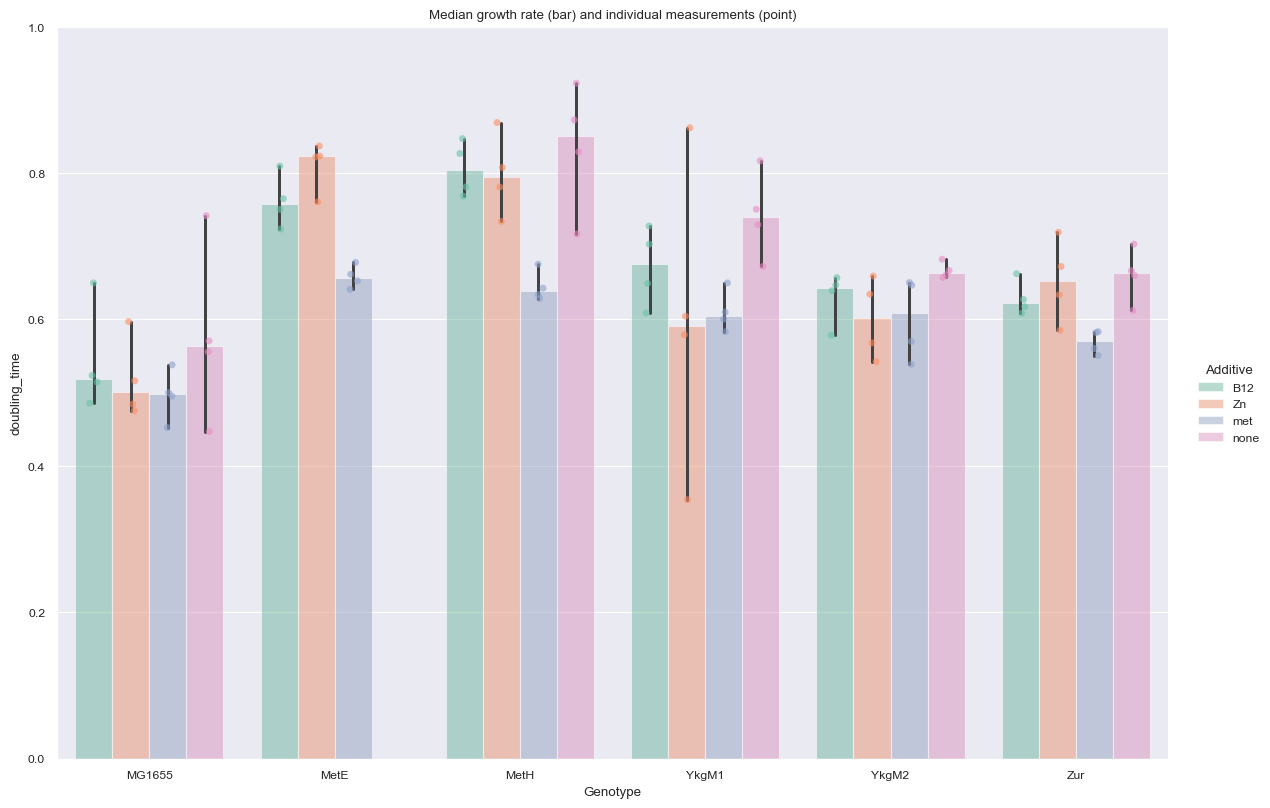

In [83]:
g = sns.catplot(x="Genotype", y="doubling_time", hue="Additive", 
                data=predicted_gr, kind="bar", estimator="median",
                height=8, aspect=1.5, alpha=0.5);
g.map_dataframe(sns.stripplot, x="Genotype", y="doubling_time", 
                hue="Additive", palette="Set2",
                alpha=0.6, dodge=True)

plt.title("Median growth rate (bar) and individual measurements (point)")
# g.map(sns.stripplot, "sex", "total_bill", "smoker", 
#       palette=["#404040"], alpha=0.6, dodge=True)
plt.ylim([0, 1])

plt.show()

## Slope fits

In [12]:
rerun_fits = False

import warnings
warnings.filterwarnings('ignore')

wells = list(f_mdf["Well"].unique())
timepoints = list(f_mdf["Time"].unique())
window = 50

well_fits = {}

if rerun_fits == True:
    for well in wells:
    
        fits = []
        
        for i, time in enumerate(timepoints):
    
            
            cur_df = f_mdf.filter(
                (pl.col("Well") == well) & 
                (pl.col("Time").is_in(timepoints[i:i+window]) )
            )
    
            fit = np.polyfit(cur_df["Time"],cur_df["Log_initial_corrected_OD"], 1)[0]
    
            fits.append(fit)
    
            # print(f"for well {well} at time {time}, the instantenous slope is {fit}")
    
        well_fits[well] = fits



In [13]:
rerun_fit_plots = False

if rerun_fit_plots == True:
    wf_df = pl.DataFrame(well_fits)
    wf_df = wf_df.with_columns(pl.arange(0, len(wf_df)).alias("Step"))
    
    
    # melt to experiments
    wf_df = wf_df.melt(id_vars="Step", variable_name="Well", value_name="Slope")
    wf_df = wf_df.with_columns((wf_df["Well"].str.slice(0,1)).alias("Row"))
    wf_df = wf_df.with_columns((wf_df["Well"].str.slice(1)).alias("Column"))
    
    wf_df = wf_df.join(adf, on="Row")
    wf_df = wf_df.join(gdf, on="Well")
    
    wf_df = wf_df.with_columns(((pl.col("Column").cast(pl.Int32)+3) % 4 + 1).alias("Replicate"))
    
    wf_df.head(5)

    sns.relplot(x="Step", y="Slope", kind="line", col="Additive", row="Genotype", height=3, \
            data=wf_df.filter(
                (pl.col("Step") > 50) & (pl.col("Step") < 200) & (pl.col("Slope") > 0)  & (pl.col("Slope") < 2.5)
            )
           )

## Test of linear fit

(0.0, 4.0)

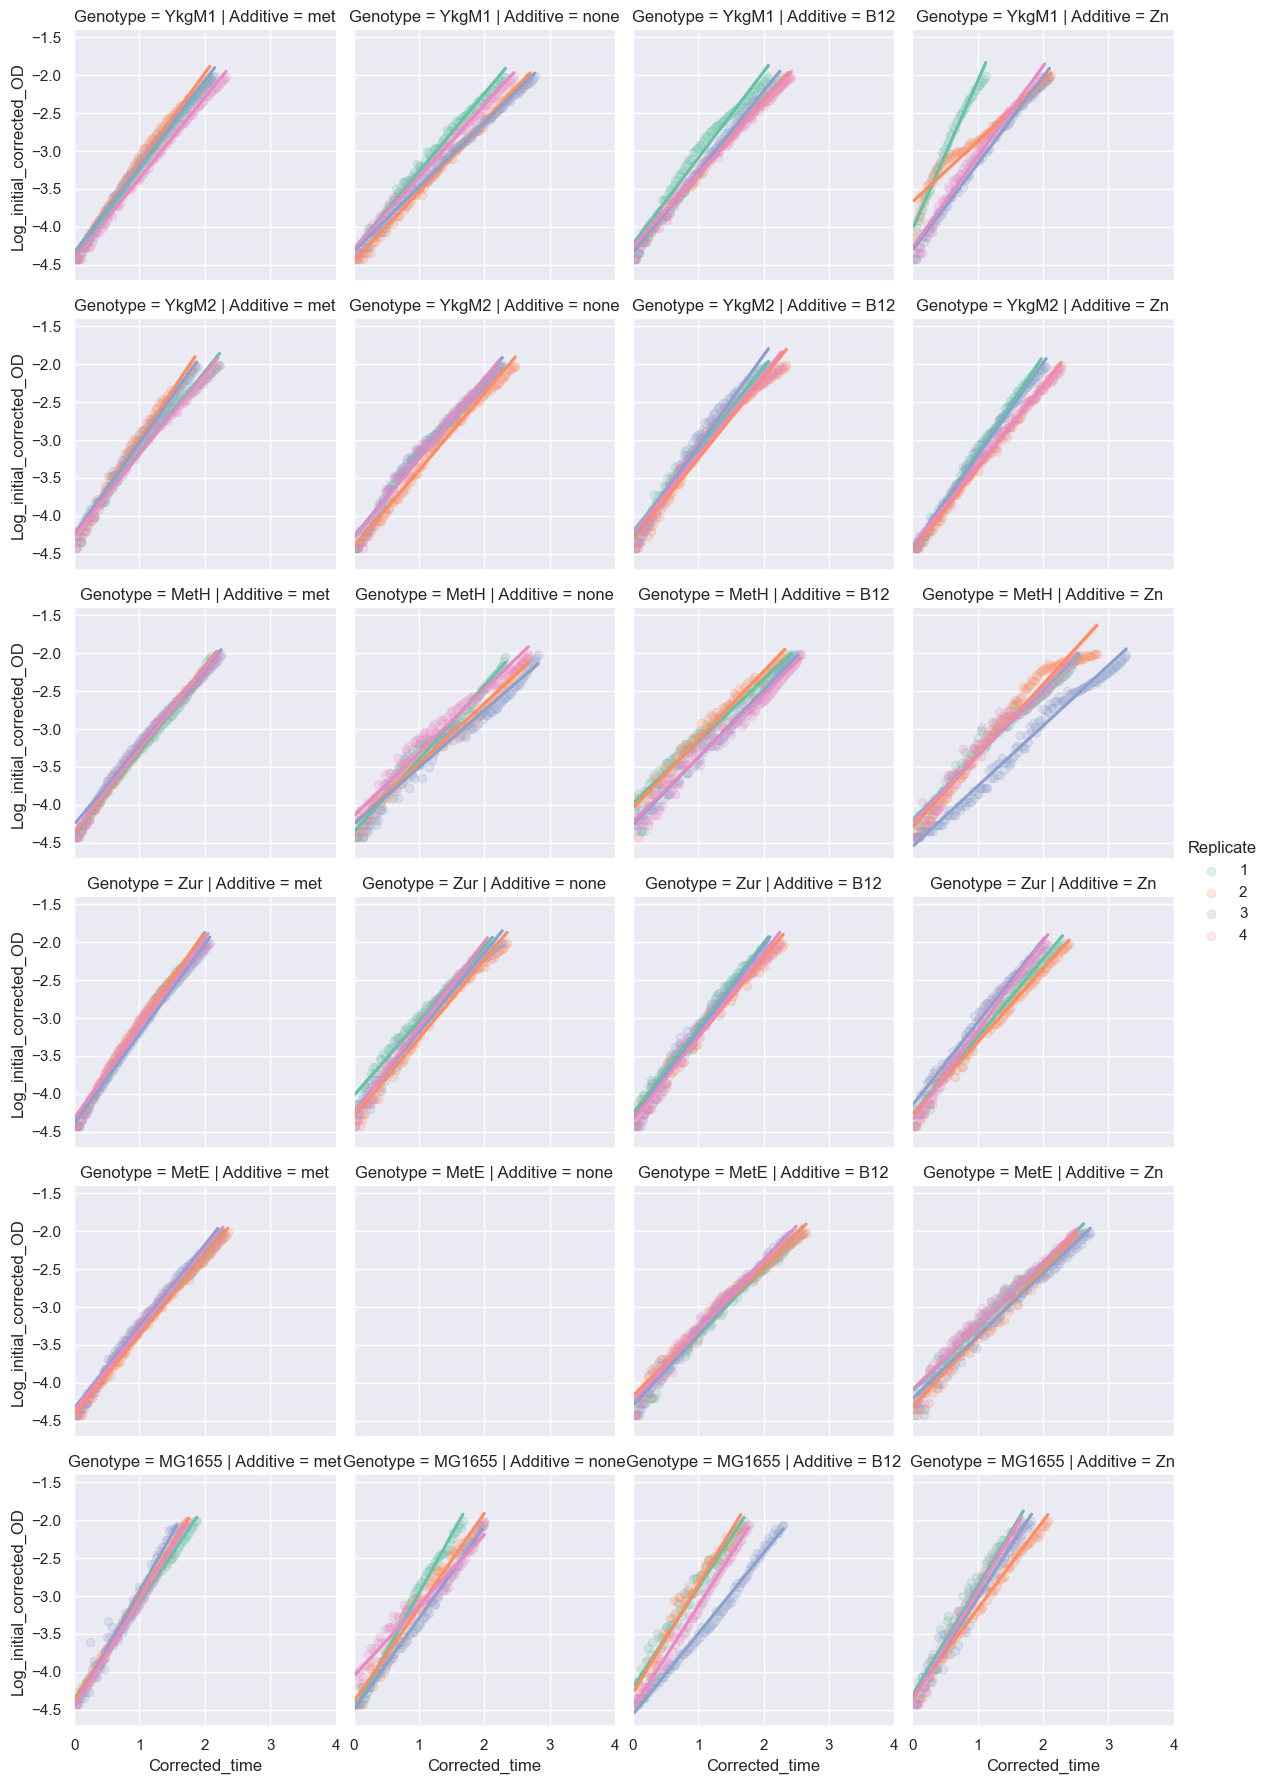

In [14]:
sns.lmplot(x="Corrected_time", y="Log_initial_corrected_OD", hue="Replicate", col="Additive", row="Genotype", height=3, \
            data=gr_df.to_pandas(), scatter_kws = {"alpha": 0.2})

plt.xlim([0,4])

# Mut

In [ ]:
additive = {"A": "met", "B": "none", "C": "B12", "D": "Zn","E": "met", "F": "none", "G": "B12", "H": "Zn"}
adf = pl.DataFrame(additive).transpose(include_header=True)
adf = adf.rename({"column": "Row", "column_0": "Additive"})

In [ ]:
genotype_row = [["A", "B", "C", "D"], ["E", "F", "G", "H"]]
genotype_col = [["1", "2", "3", "4"], ["5", "6", "7", "8"], ["9", "10", "11", "12"]]

genotype_combinations = {"YkgM1": [0, 0], "YkgM2": [0, 1], "MetH": [0, 2], "Zur": [1, 0], "MetE": [1, 1], "MG1655": [1, 2]}

In [ ]:
gdf = []

for genotype, idx in genotype_combinations.items():

    gdf.extend([[genotype, x+y] for x in genotype_row[idx[0]] for y in genotype_col[idx[1]]])

gdf

gdf = pl.DataFrame(gdf).transpose()
gdf = gdf.rename({"column_0": "Genotype", "column_1": "Well"})

In [ ]:
df = pl.read_csv("growth_data/cyrus_mutant_013124.txt", separator="\t")
df = df.drop('T600')
df.head(3)

In [ ]:
# time conversion
df = df.with_columns(pl.col("Time").str.to_time("%H:%M:%S"))
df = df.with_columns(df['Time'].dt.hour().cast(pl.Int64) + df['Time'].dt.minute().cast(pl.Int64) / 60 + df['Time'].dt.second() / 3600)

# zero by first measurement
df = df.with_columns([pl.col(c) - df[0, c] for c in df.columns])

# melt to experiments
df = df.melt(id_vars="Time", variable_name="Well", value_name="OD")
df = df.with_columns((df["Well"].str.slice(0,1)).alias("Row"))
df = df.with_columns((df["Well"].str.slice(1)).alias("Column"))

df = df.filter(pl.col("OD") > 0)

mdf = df.join(adf, on="Row")
mdf = mdf.join(gdf, on="Well")
mdf

mdf = mdf.with_columns(((pl.col("Column").cast(pl.Int32)+3) % 4 + 1).alias("Replicate"))
mdf.head(3)

In [ ]:
sns.relplot(x="Time", y="OD", hue="Replicate", kind="line", col="Additive", row="Genotype", height=3, \
            data=mdf.filter( (pl.col("Time") < 10) & (pl.col("Time") > 2) ))

In [ ]:
mdf = mdf.with_columns(pl.col("OD").log())

In [ ]:
sns.relplot(x="Time", y="OD", hue="Replicate", kind="line", col="Additive", row="Genotype", height=3, \
            data=mdf.filter( (pl.col("Time") < 10)))

In [ ]:
growth_rate_precise = mdf.filter( (pl.col("Time") < 10))

minimum_start_times = growth_rate_precise.filter(pl.col("OD") <= -4).group_by("Well").agg(pl.max("Time").alias("Time_exp_start")).sort("Time_exp_start")
minimum_end_times = growth_rate_precise.filter(pl.col("OD") >= -1).group_by("Well").agg(pl.min("Time").alias("Time_exp_end")).sort("Time_exp_end")

growth_rate_precise = growth_rate_precise.join(minimum_start_times, on="Well")
growth_rate_precise = growth_rate_precise.join(minimum_end_times, on="Well")
gr_time_filter = growth_rate_precise.filter((pl.col("Time") > pl.col("Time_exp_start")) & (pl.col("Time") < pl.col("Time_exp_end")))
gr_time_filter = gr_time_filter.with_columns((pl.col("Time") - pl.col("Time_exp_start")).alias("Corrected_time"))

# correct all od values to start at 0
# start_od = gr_time_filter.group_by("Well").agg(pl.min("OD").alias("Start_OD")).sort("Start_OD")
# gr_time_filter = gr_time_filter.join(start_od, on="Well")
# gr_time_filter = gr_time_filter.with_columns((pl.col("OD") - pl.col("Start_OD")).alias("Corrected_OD"))

# correct by linear fit

#This is what you need
correction_offset = gr_time_filter.to_pandas().groupby('Well').apply(regress, 'OD', ['Corrected_time'])
correction_offset = correction_offset.reset_index()
correction_offset = pl.DataFrame(correction_offset)

gr_time_filter

In [ ]:
sns.relplot(x="Corrected_time", y="OD", hue="Replicate", kind="line", col="Additive", row="Genotype", height=3, \
            data=gr_time_filter)

In [ ]:
sns.lmplot(x="Corrected_time", y="OD", hue="Additive", col="Genotype", col_wrap=3, height=4, 
           data=gr_time_filter.to_pandas(), scatter_kws = {"alpha": 0.2})

In [ ]:
predicted_gr = gr_time_filter \
.to_pandas().groupby(['Genotype', 'Additive','Replicate']).apply(regress_error, 'OD', ['Corrected_time'])
predicted_gr["doubling_time"] = np.log(2) / predicted_gr["slope"]
predicted_gr = predicted_gr.reset_index()


gr_mean_std = predicted_gr.groupby(['Genotype', 'Additive']).agg({'slope':['mean','std']})
gr_mean_std["doubling_time"] = np.log(2)/gr_mean_std.xs('slope',  axis=1)["mean"]
gr_mean_std

In [ ]:
g = sns.catplot(x="Genotype", y="doubling_time", hue="Additive", 
                data=predicted_gr, kind="bar",
                height=8, aspect=1.5, alpha=0.5);
g.map_dataframe(sns.stripplot, x="Genotype", y="doubling_time", 
                hue="Additive", palette="Set2",
                alpha=0.6, dodge=True)
# g.map(sns.stripplot, "sex", "total_bill", "smoker", 
#       palette=["#404040"], alpha=0.6, dodge=True)
plt.show()

# Reanalyzing the old plate lol

In [ ]:
# plate 2
df = pl.read_csv("growth_data/cyrus_012624.csv")
df = df.drop('T600')

# time conversion
df = df.with_columns(pl.col("Time").str.to_time("%H:%M:%S"))
df = df.with_columns(df['Time'].dt.hour().cast(pl.Int64) + df['Time'].dt.minute().cast(pl.Int64) / 60 + df['Time'].dt.second() / 3600)

# zero by first measurement
# df = df.with_columns([pl.col(c) - df[0, c] for c in df.columns])

# melt to experiments
df = df.melt(id_vars="Time", variable_name="Well", value_name="OD")
df = df.with_columns((df["Well"].str.slice(0,1)).alias("Experiment"))
df = df.with_columns((df["Well"].str.slice(1)).alias("Replicate"))
df = df.with_columns(pl.col("OD").log())


In [ ]:
# join with experiment type
column_names = ["Experiment", "Abb", "Description", "Pre-met", "Additive"]
conversion = [["A", "Rrm", "Rich + met, ++met", True, "met"], 
              ["B", "Rr", "Rich - met, ++met", True, "none"], 
              ["C", "RrZ", "Rich - met + Zn, ++met", True, "zinc"], 
              ["D", "Rrb", "Rich - met + B12, ++met", True, "B12"],
              ["E", "rm", "Rich + met, --met", False, "met"],
              ["F", "r", "Rich - met, --met", False, "none"],
              ["G", "rz", "Rich - met, --met", False, "zinc"],
              ["H", "rb", "Rich - met, --met", False, "B12"]]

exp = pl.DataFrame(conversion)
exp.columns = column_names

exp

In [ ]:
mdf = df.join(exp, on="Experiment")

In [ ]:
sns.relplot(x="Time", y="OD", hue="Replicate", kind="line", col="Additive", row="Pre-met", height=3, \
            data=mdf.filter( (pl.col("Time") < 10) & (pl.col("Time") > 0) ))

In [ ]:
growth_rate_precise = mdf.filter( (pl.col("Time") < 10))

minimum_start_times = growth_rate_precise.filter(pl.col("OD") <= -0.9).group_by("Well").agg(pl.max("Time").alias("Time_exp_start")).sort("Time_exp_start")
minimum_end_times = growth_rate_precise.filter(pl.col("OD") >= -0.5).group_by("Well").agg(pl.min("Time").alias("Time_exp_end")).sort("Time_exp_end")

growth_rate_precise = growth_rate_precise.join(minimum_start_times, on="Well")
growth_rate_precise = growth_rate_precise.join(minimum_end_times, on="Well")
gr_time_filter = growth_rate_precise.filter((pl.col("Time") > pl.col("Time_exp_start")) & (pl.col("Time") < pl.col("Time_exp_end")))
gr_time_filter = gr_time_filter.with_columns((pl.col("Time") - pl.col("Time_exp_start")).alias("Corrected_time"))

# correct all od values to start at 0
# start_od = gr_time_filter.group_by("Well").agg(pl.min("OD").alias("Start_OD")).sort("Start_OD")
# gr_time_filter = gr_time_filter.join(start_od, on="Well")
# gr_time_filter = gr_time_filter.with_columns((pl.col("OD") - pl.col("Start_OD")).alias("Corrected_OD"))

# correct by linear fit

#This is what you need
correction_offset = gr_time_filter.to_pandas().groupby('Well').apply(regress, 'OD', ['Corrected_time'])
correction_offset = correction_offset.reset_index()
correction_offset = pl.DataFrame(correction_offset)

gr_time_filter = gr_time_filter.join(correction_offset, on="Well")
gr_time_filter = gr_time_filter.with_columns((pl.col("OD") - pl.col("intercept")).alias("Corrected_OD"))

gr_time_filter

In [ ]:
sns.relplot(x="Corrected_time", y="OD", hue="Replicate", kind="line", col="Additive", row="Pre-met", height=3, \
            data=gr_time_filter.filter( (pl.col("Time") < 10) & (pl.col("Time") > 0) ))

In [ ]:
sns.lmplot(x="Corrected_time", y="OD", hue="Additive", col="Pre-met", col_wrap=3, height=4, 
           data=gr_time_filter.to_pandas(), scatter_kws = {"alpha": 0.2})

# All plates at once:

In [ ]:
# plate 1
df = pl.read_csv("growth_data/adrian_growth_jan25_v2.csv")
df = df.drop('T600')

# time conversion
df = df.with_columns(pl.col("Time").str.to_time("%H:%M:%S"))
df = df.with_columns(3600 * df['Time'].dt.hour().cast(pl.Int64) + 60 * df['Time'].dt.minute().cast(pl.Int64) + df['Time'].dt.second())

# zero by first measurement
df = df.with_columns([pl.col(c) - df[0, c] for c in df.columns])

# melt to experiments
df = df.melt(id_vars="Time", variable_name="Well", value_name="OD")
df = df.with_columns((df["Well"].str.slice(0,1)).alias("Experiment"))
df = df.with_columns((df["Well"].str.slice(1)).alias("Replicate"))
df = df.with_columns(Plate = pl.lit("Plate 1"))

# plate 1
df2 = pl.read_csv("growth_data/cyrus_012624.csv")
df2 = df2.drop('T600')

# time conversion
df2 = df2.with_columns(pl.col("Time").str.to_time("%H:%M:%S"))
df2 = df2.with_columns(3600 * df2['Time'].dt.hour().cast(pl.Int64) + 60 * df2['Time'].dt.minute().cast(pl.Int64) + df2['Time'].dt.second())

# zero by first measurement
df2 = df2.with_columns([pl.col(c) - df2[0, c] for c in df2.columns])

# melt to experiments
df2 = df2.melt(id_vars="Time", variable_name="Well", value_name="OD")
df2 = df2.with_columns((df2["Well"].str.slice(0,1)).alias("Experiment"))
df2 = df2.with_columns((df2["Well"].str.slice(1)).alias("Replicate"))
df2 = df2.with_columns(Plate = pl.lit("Plate 2"))

df = pl.concat([df, df2])
df

In [ ]:
# join with experiment type
column_names = ["Experiment", "Abb", "Description", "Pre-met", "Additive"]
conversion = [["A", "Rrm", "Rich + met, ++met", True, "met"], 
              ["B", "Rr", "Rich - met, ++met", True, "none"], 
              ["C", "RrZ", "Rich - met + Zn, ++met", True, "zinc"], 
              ["D", "Rrb", "Rich - met + B12, ++met", True, "B12"],
              ["E", "rm", "Rich + met, --met", False, "met"],
              ["F", "r", "Rich - met, --met", False, "none"],
              ["G", "rz", "Rich - met, --met", False, "zinc"],
              ["H", "rb", "Rich - met, --met", False, "B12"]]

exp = pl.DataFrame(conversion)
exp.columns = column_names


In [ ]:
mdf = df.join(exp, on="Experiment")

In [ ]:
sns.relplot(x="Time", y="OD", hue="Plate", style="Replicate", kind="line", row="Pre-met", col="Additive", height=3, \
            data=mdf.filter(
                (pl.col("Time")<20000) & 
                (pl.col("Replicate") != "3")
           ))

In [ ]:
growth_rate_precise = data=mdf.filter(
                (pl.col("Time")<40000) 
           )

growth_rate_precise = growth_rate_precise.with_columns(pl.concat_str([pl.col("Well"), pl.col("Plate")], separator=",").alias("Unique_well"))

minimum_start_times = growth_rate_precise.filter(pl.col("OD") <= 0.08).group_by("Unique_well").agg(pl.max("Time").alias("Time_exp_start")).sort("Time_exp_start")
minimum_end_times = growth_rate_precise.filter(pl.col("OD") >= 0.35).group_by("Unique_well").agg(pl.min("Time").alias("Time_exp_end")).sort("Time_exp_end")

growth_rate_precise = growth_rate_precise.join(minimum_start_times, on="Unique_well")
growth_rate_precise = growth_rate_precise.join(minimum_end_times, on="Unique_well")
gr_time_filter = growth_rate_precise.filter((pl.col("Time") > pl.col("Time_exp_start")) & (pl.col("Time") < pl.col("Time_exp_end")))
gr_time_filter = gr_time_filter.with_columns((pl.col("Time") - pl.col("Time_exp_start")).alias("Corrected_time"))

# correct all od values to start at 0
# start_od = gr_time_filter.group_by("Well").agg(pl.min("OD").alias("Start_OD")).sort("Start_OD")
# gr_time_filter = gr_time_filter.join(start_od, on="Well")
# gr_time_filter = gr_time_filter.with_columns((pl.col("OD") - pl.col("Start_OD")).alias("Corrected_OD"))

# correct by linear fit

#This is what you need
correction_offset = gr_time_filter.to_pandas().groupby('Unique_well').apply(regress, 'OD', ['Corrected_time'])
correction_offset = correction_offset.reset_index()
correction_offset = pl.DataFrame(correction_offset)

gr_time_filter = gr_time_filter.join(correction_offset, on="Unique_well")
gr_time_filter = gr_time_filter.with_columns((pl.col("OD") - pl.col("intercept")).alias("Corrected_OD"))

gr_time_filter

In [ ]:
sns.lmplot(x="Corrected_time", y="Corrected_OD", hue="Replicate", col="Additive", row="Pre-met", height=4,
           data=gr_time_filter.filter((pl.col("Plate") == "Plate 1")).to_pandas())

In [ ]:
predicted_gr = gr_time_filter.filter((pl.col("Plate") == "Plate 1") & (pl.col("Pre-met") == False)).to_pandas().groupby(['Additive', 'Plate', 'Pre-met']).apply(regress_error, 'Corrected_OD', ['Corrected_time'])
predicted_gr = predicted_gr.reset_index()

predicted_gr

# Plate two

In [ ]:
df = pl.read_csv("growth_data/cyrus_012624.csv")
df = df.drop('T600')
df

In [ ]:
bf = pl.read_csv("growth_data/cyrus_012624_blanks.csv")
bf = bf.drop('T600')
bfm = bf.mean()
bfm[0, "Time"] = 0
bfm = bfm.with_columns(bfm["Time"].cast(pl.Int64))

In [ ]:
df = pl.read_csv("growth_data/cyrus_012624.csv")
df = df.drop('T600')
df

# time conversion
df = df.with_columns(pl.col("Time").str.to_time("%H:%M:%S"))
df = df.with_columns(3600 * df['Time'].dt.hour().cast(pl.Int64) + 60 * df['Time'].dt.minute().cast(pl.Int64) + df['Time'].dt.second())

# zero by first measurement
df = df.with_columns([pl.col(c) - df[0, c] for c in df.columns])

# melt to experiments
df = df.melt(id_vars="Time", variable_name="Well", value_name="OD")
df = df.with_columns((df["Well"].str.slice(0,1)).alias("Experiment"))
df = df.with_columns((df["Well"].str.slice(1)).alias("Replicate"))
df

df

In [ ]:
# join with experiment type
column_names = ["Experiment", "Abb", "Description", "Pre-met", "Additive"]
conversion = [["A", "Rrm", "Rich + met, ++met", True, "met"], 
              ["B", "Rr", "Rich - met, ++met", True, "none"], 
              ["C", "RrZ", "Rich - met + Zn, ++met", True, "zinc"], 
              ["D", "Rrb", "Rich - met + B12, ++met", True, "B12"],
              ["E", "rm", "Rich + met, --met", False, "met"],
              ["F", "r", "Rich - met, --met", False, "none"],
              ["G", "rz", "Rich - met, --met", False, "zinc"],
              ["H", "rb", "Rich - met, --met", False, "B12"]]

exp = pl.DataFrame(conversion)
exp.columns = column_names

exp

In [ ]:
mdf = df.join(exp, on="Experiment")

In [ ]:
sns.relplot(x="Time", y="OD", kind="line",  hue="Additive", col="Pre-met", height=6, col_wrap=2, data=mdf.filter(pl.col("Time")<15000))

In [ ]:
sns.relplot(x="Time", y="OD", hue="Replicate", kind="line", row="Pre-met", col="Additive", height=3, \
            data=mdf.filter(
                (pl.col("Time")<20000) & 
                (pl.col("Replicate") != "3")
           ))

In [ ]:
growth_rate_precise = data=mdf.filter(
                (pl.col("Time")<20000) 
           )


minimum_start_times = growth_rate_precise.filter(pl.col("OD") <= 0.06).group_by("Well").agg(pl.max("Time").alias("Time_exp_start")).sort("Time_exp_start")
minimum_end_times = growth_rate_precise.filter(pl.col("OD") >= 0.30).group_by("Well").agg(pl.min("Time").alias("Time_exp_end")).sort("Time_exp_end")

growth_rate_precise = growth_rate_precise.join(minimum_start_times, on="Well")
growth_rate_precise = growth_rate_precise.join(minimum_end_times, on="Well")
gr_time_filter = growth_rate_precise.filter((pl.col("Time") > pl.col("Time_exp_start")) & (pl.col("Time") < pl.col("Time_exp_end")))
gr_time_filter = gr_time_filter.with_columns((pl.col("Time") - pl.col("Time_exp_start")).alias("Corrected_time"))

# correct all od values to start at 0
# start_od = gr_time_filter.group_by("Well").agg(pl.min("OD").alias("Start_OD")).sort("Start_OD")
# gr_time_filter = gr_time_filter.join(start_od, on="Well")
# gr_time_filter = gr_time_filter.with_columns((pl.col("OD") - pl.col("Start_OD")).alias("Corrected_OD"))

# correct by linear fit

#This is what you need
correction_offset = gr_time_filter.to_pandas().groupby('Well').apply(regress, 'OD', ['Corrected_time'])
correction_offset = correction_offset.reset_index()
correction_offset = pl.DataFrame(correction_offset)

gr_time_filter = gr_time_filter.join(correction_offset, on="Well")
gr_time_filter = gr_time_filter.with_columns((pl.col("OD") - pl.col("intercept")).alias("Corrected_OD"))

gr_time_filter

In [ ]:
sns.relplot(x="Corrected_time", y="Corrected_OD", hue="Replicate", kind="line", row="Pre-met", col="Additive", height=3, \
            data=gr_time_filter)

In [ ]:
sns.lmplot(x="Corrected_time", y="Corrected_OD", hue="Replicate", col="Additive", row="Pre-met", height=4,data=gr_time_filter.to_pandas())

In [ ]:
sns.lmplot(x="Corrected_time", y="Corrected_OD", hue="Additive", row="Pre-met", height=4,data=gr_time_filter.to_pandas())

In [ ]:
predicted_gr = gr_time_filter.to_pandas().groupby('Additive').apply(regress_error, 'Corrected_OD', ['Corrected_time'])
predicted_gr = predicted_gr.reset_index()

predicted_gr

# 2nd round, different overnight media +/- met

In [ ]:
bf = pl.read_csv("growth_data/adrian_growth_jan25_blanks.csv")
bf = bf.drop('T� 600')
bfm = bf.mean()
bfm[0, "Time"] = 0
bfm = bfm.with_columns(bfm["Time"].cast(pl.Int64))

In [ ]:
df = pl.read_csv("growth_data/adrian_growth_jan25_v2.csv")
df = df.drop('T∞ 600')
df

In [ ]:
df = df.with_columns(pl.col("Time").str.to_time("%H:%M:%S"))
df = df.with_columns(3600 * df['Time'].dt.hour().cast(pl.Int64) + 60 * df['Time'].dt.minute().cast(pl.Int64) + df['Time'].dt.second())

df

In [ ]:
df = df.with_columns([pl.col(c) - df[0, c] for c in df.columns])

In [ ]:
df = df.melt(id_vars="Time", variable_name="Well", value_name="OD")
df = df.with_columns((df["Well"].str.slice(0,1)).alias("Experiment"))
df = df.with_columns((df["Well"].str.slice(1)).alias("Replicate"))
df

In [ ]:
sns.relplot(x="Time", y="OD", hue="Replicate", kind="line", col="Experiment", col_wrap=4, height=3, data=df.filter(pl.col("Time")<30000))

In [ ]:
sns.relplot(x="Time", y="OD", hue="Experiment", kind="line", height=10, data=df.filter(pl.col("Time")<15000))

R	First overnight culture in rich + met (otherwise overnight was in media without met)

r	rich

m	met

z	with Zn

z	with B12

In [ ]:
column_names = ["Experiment", "Abb", "Description", "Pre-met", "Additive"]
conversion = [["A", "Rrm", "Rich + met, ++met", True, "met"], 
              ["B", "Rr", "Rich - met, ++met", True, "none"], 
              ["C", "RrZ", "Rich - met + Zn, ++met", True, "zinc"], 
              ["D", "Rrb", "Rich - met + B12, ++met", True, "B12"],
              ["E", "rm", "Rich + met, --met", False, "met"],
              ["F", "r", "Rich - met, --met", False, "none"],
              ["G", "rz", "Rich - met, --met", False, "zinc"],
              ["H", "rb", "Rich - met, --met", False, "B12"]]

exp = pl.DataFrame(conversion)
exp.columns = column_names

exp

In [ ]:
mdf = df.join(exp, on="Experiment")

In [ ]:
sns.relplot(x="Time", y="OD", kind="line", col="Pre-met", hue="Additive", style="Replicate", height=6, data=mdf.filter(pl.col("Time")<15000))

In [ ]:
sns.relplot(x="Time", y="OD", kind="line",  hue="Additive", col="Pre-met", height=6, col_wrap=2, data=mdf.filter(pl.col("Time")<15000))

In [ ]:
pdf = mdf.filter((pl.col("Time")<15000) & (pl.col("Time") > 10000)).to_pandas()

In [ ]:
sns.lmplot(x="Time", y="OD", hue="Additive", col="Pre-met", height=6, col_wrap=2, data=pdf)

In [ ]:
sns.relplot(x="Time", y="OD", kind="line", col="Additive", hue="Pre-met", height=6, col_wrap=2, data=mdf.filter(pl.col("Time")<15000))

In [ ]:
meta = pl.read_csv("growth_data/adrian_growth_jan25_indicator.csv")
meta = meta.melt(id_vars='row', variable_name="col", value_name="experiment")
meta = meta.drop_nulls()
meta

In [ ]:
df = pd.read_csv("growth_data/adrian_growth_jan25_v2.csv")
df = df.drop(['T∞ 600'], axis=1)
df["Time"] = pd.to_datetime(df['Time'],format= '%H:%M:%S', coerce=).dt.time

In [ ]:
pd.to_datetime(df['Time'],format= '%H:%M:%S').dt.time

In [ ]:
df = pd.read_csv("growth_data/adrian_growth_jan24.csv")
df = df.dropna()
df

In [ ]:
df = df.loc[:, ["Series1", "Series2", "Series3", "Series4", "Series5", "Series6", "Time_seconds", "ID"]]

In [ ]:
df = df.melt(id_vars=["Time_seconds", "ID"], var_name="Series", value_name="OD")
df = df.rename(columns={"Time_seconds": "Time", "ID": "Experiment"})

for k, v in {"RM": "+met", "RZ": "+Zn", "RB": "+B12", "R": "-met", }.items():
    df["Experiment"] = df["Experiment"].str.replace(k, v)

df

In [ ]:
df_truncated = df.copy()

df_truncated.loc[df_truncated["Experiment"].isin(["+B12", "+Zn"]), "Time"] = \
df_truncated.loc[df_truncated["Experiment"].isin(["+B12", "+Zn"]), "Time"] +1100


df_truncated = df_truncated.loc[df_truncated["Time"].between(7500, 100000), :]


sns.relplot(x="Time", y="OD", hue="Experiment", kind="line", data=df_truncated, height=8)

In [ ]:
df_truncated = df.copy()

df_truncated.loc[df_truncated["Experiment"].isin(["+B12", "+Zn"]), "Time"] = df_truncated.loc[df_truncated["Experiment"].isin(["+B12", "+Zn"]), "Time"] +1000

df_truncated = df_truncated.loc[df_truncated["Time"].between(7500, 20000), :]



sns.relplot(x="Time", y="OD", hue="Experiment", style="Series", col="Experiment", kind="line", col_wrap=2, data=df_truncated, height=4
        )